# Cellohood Tutorial

In this notebook we will show an example Cellohood analysis, based on the one performed for Van Renne et al.

Let us start with data preparation:

**STEP 0.1:** Download the IMC data from [Zenodo](https://zenodo.org/records/17526362) and set appropriate data paths below:

- `CSV_PATH` - path to preprocessed IMC Panel 1 csvs,
- `CLINICAL_DATA_DF` - path to a clinical data xlsx file.

In [1]:
CSV_PATH = '/raid/immucan/IMC/BC-final/Synergy/BC1/IMC1/csv'
CLINICAL_DATA_DF = '/raid/immucan/immuw/data/synergy_meta_data_for_IMC.xlsx'

**STEP 0.2:** in rare cases when you don't want to use GPUs `Cellohood` (or run them on specific devices) set this variable appropriately (this is required as `tensorflow` resolves GPUs at the moment when `cellohood` package is loaded):

In [2]:
import os


os.environ['CUDA_VISIBLE_DEVICES'] = ''

## Data loading:

In this part we will combine all of the IMC dfs into a single `pandas.DataFrame`.

Let's start with data loading:

In [3]:
from collections import defaultdict

import pandas


def get_clean_entry(x):
    try:
        return float(x)
    except:
        return x

def load_dataframe_from_path(path):
    result = defaultdict(list)
    with open(path, 'r') as f_handle:
        lines = f_handle.readlines()
        columns = lines[0].replace("\n", "").split(',')
        col_shape = len(columns) 
        for line in lines[1:]:
            entries = line.replace("\n", "").split(',')[:col_shape]
            for col, entry in zip(columns, entries):
                result[col].append(get_clean_entry(entry))
    return pandas.DataFrame(result)


rcs, cms = {}, {}

for path in os.listdir(CSV_PATH):
    if not path.endswith('csv'):
        continue
    sample_name = path.split('_#')[0]
    try:
        if 'cell_metadata' in path:
            cms[sample_name] = load_dataframe_from_path(os.path.join(CSV_PATH, path))
        elif 'raw_counts' in path:
            rcs[sample_name] = load_dataframe_from_path(os.path.join(CSV_PATH, path))
    except:
        print(f'Failed for {path}')

.. and merging `cell_metadata` and `raw_counts` dfs:

In [4]:
data_dfs = []
samples = []


for sample in rcs:
    try:
        if 'Unnamed: 1' in cms:
            cms['Unnamed: 0'] = cms['Unnamed: 1']
            print(sample)
        cms[sample]['sample_immu'] = sample
        data_dfs.append(pandas.merge(cms[sample], rcs[sample]))
        samples.append(sample)
    except:
        print(f'Failed for {sample}')

Now - let's merge everything into the final table:

In [5]:
data_df = pandas.concat(
    data_dfs
)

The final data consist of this number of cells from this number of images:

In [6]:
data_df.shape[0], data_df.groupby('image').count().shape[0]

(672666, 284)

## Setting up the variables / Cellohood paths

Let us start with defining the list of used markers. Note that it is crucual data `data_df` have this markers as columns:

In [7]:
MARKER_COL_NAMES = [
       'MPO', 'HistoneH3', 'SMA', 'CD16', 'CD38', 'HLADR',
       'CD27', 'CD15', 'CD45RA', 'CD163', 'B2M', 'CD20', 'CD68', 'Ido1', 'CD3',
       'LAG3', 'CD11c', 'PD1', 'PDGFRb', 'CD7', 'GrzB', 'PDL1', 'TCF7',
       'CD45RO', 'FOXP3', 'ICOS', 'CD8a', 'CarbonicAnhydrase', 'CD33', 'Ki67',
       'VISTA', 'CD40', 'CD4', 'CD14', 'Ecad', 'CD303', 'CD206', 'cleavedPARP',
       'DNA1', 'DNA2'
]

Now let's define:

- `DISTANCE_THRESHOLD` - the diameter of a cell bag that you want to use,
- `POS_COL_NAMES` - the tuple of columns indicating cell spatial positions,
- `IMAGE_ID_COLUMN`- the column in `data_df` indicating the name of the image from which a given cell comes from,
- `SAMPLE_COL_NAME` - if a single patient / sample has multiple images - indicate it name here. If every patient / sample has only a single image - set it the same as `IMAGE_ID_COLUMN`.

In [8]:
DISTANCE_THRESHOLD = 25.
POS_COL_NAMES = ['Pos_X', 'Pos_Y']
IMAGE_ID_COLUMN = 'image'
SAMPLE_COL_NAME = 'image'

Now, let's define `Cellohood` objects related paths.

The main object that `Cellohood` uses is a `BagCelloDf` - that is a wrapper on `cell_df`:

- `LOAD_CELLO_BAG_DF` - it indicates if you want to use a precomputed `BagCelloDf` or compute it from the scratch.
- `FULL_CELLO_BAG_DF_PATH` - it provides either a path from which the `BagCelloDf` is loaded or where it is saved.
- `APPLY_ARCSINH_TRANSFORM` - indicates if `arcsinh(x / 5.)` transform is applied to marker expressions.

In [9]:
LOAD_CELLO_BAG_DF = True
FULL_CELLO_BAG_DF_PATH = 'synergy_cello_bag_df'
APPLY_ARCSINH_TRANSFORM = True

Now let's indicate if we want to train the model from scratch or load it (indicated by `TRAIN_MODEL` variable), and where to load it from / save it to (indicated by `SAVING_PATH`):

In [10]:
TRAIN_MODEL = False
SAVING_PATH = 'CelloSynnergy'

Now - let's do the same for the `PLDA` analysis:

In [11]:
TRAIN_LATENT_DIRECTIONS = False
LD_SAVING_PATH = 'synnergy_ld.pickle'

Now we are ready to load `BagCelloDf`:

In [12]:
import cellohood


if not LOAD_CELLO_BAG_DF:
    bag_cello_df = cellohood.transform_df_to_bag_cello_df(
        df_=data_df,
        image_id_column=IMAGE_ID_COLUMN,
        pos_col_names=POS_COL_NAMES,
        distance_threshold=DISTANCE_THRESHOLD,
        marker_col_names=MARKER_COL_NAMES,
    )
    if APPLY_ARCSINH_TRANSFORM:
        bag_cello_df = cellohood.apply_arcsinh_to_bag_cello_df(bag_cello_df)
    cellohood.save_bag_cello_df(bag_cello_df=bag_cello_df, path=FULL_CELLO_BAG_DF_PATH, exist_ok=True)
else:
    bag_cello_df = cellohood.load_bag_cello_df(path=FULL_CELLO_BAG_DF_PATH)

We can potentially split if for training / test analyses. Split is performed on the sample / patient level:

In [13]:
train_bag_cello_df, test_bag_cello_df = cellohood.split_bag_cello_df_by(
    bag_cello_df,
    by=SAMPLE_COL_NAME,
    split_percentage=1.,
)

Now - we are ready for a data standarization (by default the markers are z-scored):

In [14]:
standardized_cello_dfs = cellohood.standardize_bag_cello_df(
    train_bag_cello_df=train_bag_cello_df, 
    test_bag_cello_df=test_bag_cello_df,
    marker_col_names=MARKER_COL_NAMES,
)

Now - we are ready to train and save the model / load it (depending on `TRAIN_MODEL` variable):

In [15]:
if TRAIN_MODEL:
    cello_train_result = cellohood.train(
        standardized_cello_dfs=standardized_cello_dfs,
        epoch_nb=1000,
        use_cuda=True,
    )
    cellohood.save_cello_train_result(cello_train_result, SAVING_PATH)
else:
    cello_train_result = cellohood.load_cello_train_result(SAVING_PATH)

{'output_size': 40, 'max_neighborhood_size': 11, 'latent_size': 64, 'layer_size': 128, 'intermediate_layer_size': 256}


2025-11-14 13:23:58.842419: E tensorflow/stream_executor/cuda/cuda_driver.cc:271] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2025-11-14 13:23:58.842471: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:169] retrieving CUDA diagnostic information for host: rudy
2025-11-14 13:23:58.842482: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:176] hostname: rudy
2025-11-14 13:23:58.842649: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:200] libcuda reported version is: 535.230.2
2025-11-14 13:23:58.842687: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:204] kernel reported version is: 535.230.2
2025-11-14 13:23:58.842696: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:310] kernel version seems to match DSO: 535.230.2
/raid/immucan/immuw/cellohood_venv/lib/python3.8/site-packages/keras/engine/training_v1.py:2079: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorF

Now - we will run `Cellohood` predictions on all cells:

In [16]:
cello_prediction = cellohood.run_prediction_on_cello_df(
    cello_train_result,
    bag_cello_df,
)

/raid/immucan/immuw/cellohood_venv/lib/python3.8/site-packages/keras/engine/training_v1.py:2079: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates=self.state_updates,


Now - we will spatially smooth the Cellohood predictions. Note - to speed up the computations - Cellohood caches partial computations in `TEMPORAL_CACHE_DIR` directory, that is removed after smoothing:

In [17]:
TEMPORAL_CACHE_DIR = 'synnergy_cache'

smoothed_df_result = cellohood.smooth_cellohood_prediction(
    cello_prediction,
    distance_threshold=DISTANCE_THRESHOLD,
    cache_path=TEMPORAL_CACHE_DIR,
)

!rm -r $TEMPORAL_CACHE_DIR

Now we are ready to obtain / reload the PLDA analysis objects.

For this analysis it's worth to specify:

- `EXPLAINED_VARIANCE_LEVELS` - tuple of variance levels that we would like to explore,
- `MIN_NB_OF_CLUSTERS, MAX_NB_OF_CLUSTERS, CLUSTER_STEP` - we will explore potential `MIN_NB_OF_CLUSTERS, MIN_NB_OF_CLUSTERS + CLUSTER_STEP, MIN_NB_OF_CLUSTERS + 2 * CLUSTER_STEP, ..., MAX_NB_OF_CLUSTERS` number of clusters,
- `NB_OF_TRIES_PER_CLUSTER_NB` - how many independent runs should be performed per single number of clusters candidate.
- `TAKE_EVERY_EXAMPLE_PER_TRAINING` - downsampling factor - to speed up the computations.

In [18]:
import joblib


EXPLAINED_VARIANCE_LEVELS = (0.5, 0.75, 1.)

MIN_NB_OF_CLUSTERS = 5
MAX_NB_OF_CLUSTERS = 30
CLUSTER_STEP = 1

NB_OF_TRIES_PER_CLUSTER_NB = 5
TAKE_EVERY_EXAMPLE_PER_TRAINING = 200

if TRAIN_LATENT_DIRECTIONS:
    latent_direction_result = cellohood.get_latent_directions(
        df=smoothed_df_result.cell_predictions,
        columns=smoothed_df_result.cello_columns,
        explained_variance_levels=EXPLAINED_VARIANCE_LEVELS,
        min_nb_of_clusters=MIN_NB_OF_CLUSTERS,
        max_nb_of_clusters=MAX_NB_OF_CLUSTERS,
        nb_of_tries_per_cluster_nb=NB_OF_TRIES_PER_CLUSTER_NB,
        take_every_example_for_training=TAKE_EVERY_EXAMPLE_PER_TRAINING,
        clusters_step=CLUSTER_STEP,
    )
    joblib.dump(latent_direction_result, LD_SAVING_PATH)
else:
    latent_direction_result = joblib.load(LD_SAVING_PATH)

Now - let's have a look at candidate number of clusters at each level of explained variance:

In [19]:
cellohood.summarize_latent_direction_result(latent_direction_result)

Latent Direction Summary:
Variance: 0.5 (dim=6), selected clusters = [10, 12, 18, 23].
Variance: 0.75 (dim=14), selected clusters = [13, 19, 23, 27].
Variance: 1.0 (dim=64), selected clusters = [10, 18, 21, 23, 27].


and select the clusterings that we would like to analyze, and extend the .. with appropriate predictions:

In [20]:
variance_to_nb_of_clusters = {
    0.5: [10],
    0.75: [13],
    1.0: [21, 27],
}

for variance, nbs_of_clusters in variance_to_nb_of_clusters.items():
    for nb_of_clusters in nbs_of_clusters:
        bag_cello_df.cell_df[f'{variance}:{nb_of_clusters}'] = cellohood.get_latent_directions_predictions(
            latent_direction_result=latent_direction_result,
            explained_variance=variance,
            selected_number_of_clusters=nb_of_clusters,
        )

(for the analysis it's handy to add an artifical `DUMMY_COL_NAME` columns filled with 1s):

In [21]:
DUMMY_COL_NAME = 'Dummy'

cell_df = bag_cello_df.cell_df 
cell_df[DUMMY_COL_NAME] = 1

Before jumping into analyses, let's set up a set of data / plotting related variables:

In [22]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_context("paper", rc={"font.size": 6, "axes.titlesize":6,"axes.labelsize":6})  
plt.rcParams['legend.title_fontsize'] = 6
plt.rcParams['legend.fontsize'] = 6


matplotlib.font_manager.fontManager.addfont('/raid/immucan/immuw/Arial.ttf')  # if you need to add the font file
plt.rcParams['font.family'] = 'Arial'


marker_color_norm = matplotlib.colors.Normalize(vmin=-2, vmax=2)
marker_cmap = plt.get_cmap('coolwarm')

marker_sm = matplotlib.cm.ScalarMappable(norm=marker_color_norm, cmap=marker_cmap)


def transform_vec_to_colors(
    vec,
    colors,
    standarize=True,
    display=None,
    permute=None,
    ignore_color=(160 / 255, 160 / 255, 160 / 255),
):
    if standarize:
        display = display if display is not None else numpy.arange(len(vec))
        vec = vec.copy()
        vec = vec - numpy.mean(vec[display])
        vec = vec / numpy.std(vec[display])
    result = [
        colors.to_rgba(x)
        for x in vec
    ]
    if display is not None:
        new_result = []
        for ind_, result_col in enumerate(result):
            current_color = list(result_col)
            if ind_ in display:
                pass 
            else:
                current_color = ignore_color
            new_result.append(current_color)
            
        result = new_result
    if permute:
        result = [
            result[i]
            for i in permute
        ]
    return result



CELLTYPE_COLNAME = 'celltypes'
CELLTYPE_PLOT_NAME = 'Cell type'
MARKER_PLOT_NAME = 'Marker'
ALL_PLOT_NAME = 'All'
PLOTTING_DPI = 300

## PLDA Analysis

Let's select `PREDICTION_VARIANCE_LEVEL` and `PREDICTION_NB_OF_CLUSTERS` for the analyses:

In [23]:
PREDICTION_NB_OF_CLUSTERS = 27
PREDICTION_VARIANCE_LEVEL = 1.0

PREDICTION_CLUSTER_COLUMN = f'{PREDICTION_VARIANCE_LEVEL}:{PREDICTION_NB_OF_CLUSTERS}'

### Cell type abundances / percentages:

Let's compute and visualize the CNs cell type abundances and percentages.

Computations:

In [24]:
celltype_counts = pandas.pivot_table(
    cell_df, 
    values=DUMMY_COL_NAME, 
    index=[PREDICTION_CLUSTER_COLUMN],
    columns=[CELLTYPE_COLNAME],
    aggfunc="sum",
).fillna(0)

celltype_percentages = (celltype_counts.T / celltype_counts.sum(axis=1)).T
celltype_percentages.columns.name = CELLTYPE_PLOT_NAME

celltypes = list(celltype_percentages.columns)

Visualization:

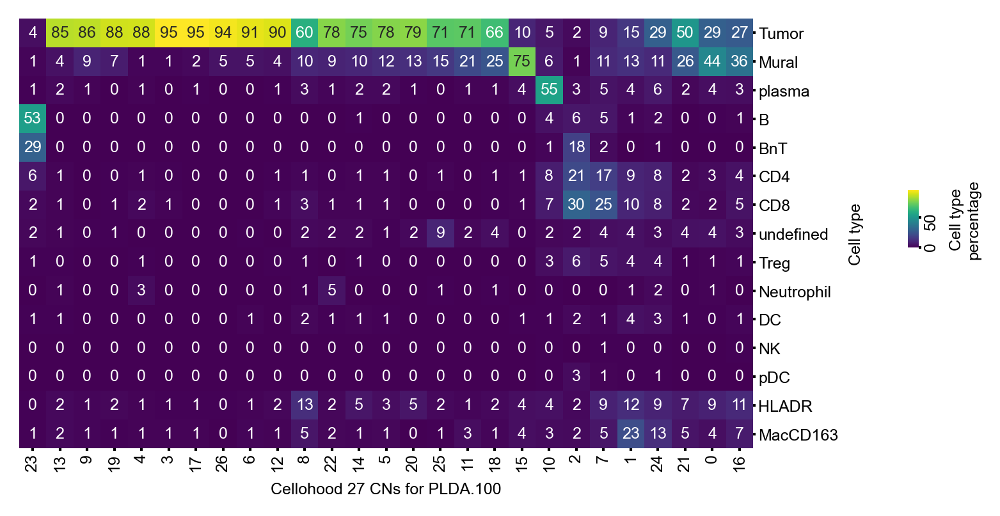

In [25]:
celltype_clustermap = sns.clustermap(
    celltype_percentages[celltypes].T * 100, 
    annot=True,
    fmt='.0f',
    cmap='viridis',
    cbar_pos=(1.05, 0.4, 0.01, 0.1),
    annot_kws={"size": 6},
    cbar_kws={'label': 'Cell type\npercentage'}
)

celltype_clustermap.ax_cbar.tick_params(labelsize=6, size=1, pad=1, rotation=90)
celltype_clustermap.ax_row_dendrogram.set_visible(False)
celltype_clustermap.ax_col_dendrogram.set_visible(False)

celltype_clustermap.ax_heatmap.set_yticklabels(celltype_clustermap.ax_heatmap.get_yticklabels(), size=6)
celltype_clustermap.ax_heatmap.xaxis.set_tick_params(size=1, left=True, pad=1)
celltype_clustermap.ax_heatmap.yaxis.set_tick_params(size=1, pad=1, rotation=0)
celltype_clustermap.ax_heatmap.set_xticklabels(celltype_clustermap.ax_heatmap.get_xticklabels(), size=6, rotation=90)
celltype_clustermap.ax_heatmap.set_xlabel(f'Cellohood {PREDICTION_NB_OF_CLUSTERS} CNs for PLDA.{int(100 * PREDICTION_VARIANCE_LEVEL)}')


celltype_clustermap.fig.set_dpi(PLOTTING_DPI)
celltype_clustermap.fig.set_size_inches((0.2 * PREDICTION_NB_OF_CLUSTERS, 0.2 * len(celltypes)))

### Per CNs and general marker expressions

We will now compute the cell type agnostic marker profiles:

In [26]:
all_markers_distribution = cell_df.groupby([PREDICTION_CLUSTER_COLUMN]).mean()[MARKER_COL_NAMES]
all_markers_distribution -= all_markers_distribution.mean()
all_markers_distribution /= all_markers_distribution.std()
all_markers_distribution.columns = MARKER_COL_NAMES

/tmp/ipykernel_648838/1319297407.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  all_markers_distribution = cell_df.groupby([PREDICTION_CLUSTER_COLUMN]).mean()[MARKER_COL_NAMES]


.. and visualize them:

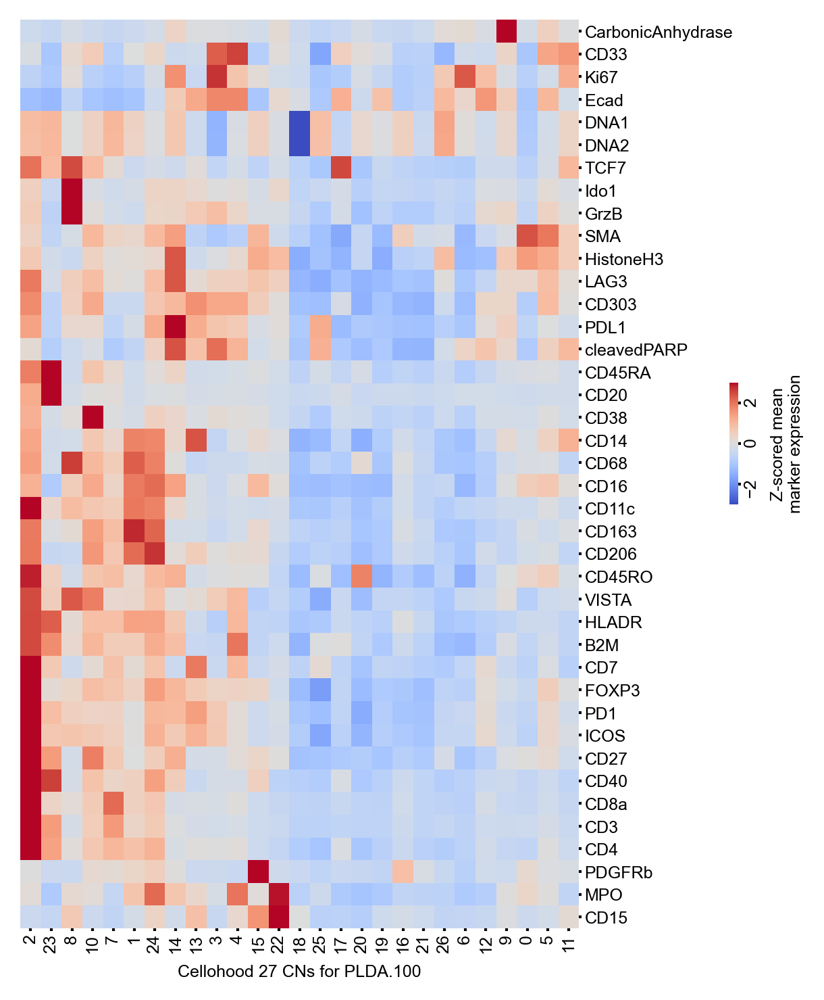

In [27]:
all_markers_map = sns.clustermap(
    all_markers_distribution.T, 
    center=0, 
    cmap='coolwarm',
    vmin=-3, 
    vmax=3, 
    yticklabels=True,
    cbar_pos=(1.05, 0.4, 0.01, 0.1),
    annot_kws={"size": 6},
    cbar_kws={'label': 'Z-scored mean\nmarker expression'}
)

all_markers_map.ax_cbar.tick_params(labelsize=6, size=1, pad=1, rotation=90)
all_markers_map.ax_row_dendrogram.set_visible(False)
all_markers_map.ax_col_dendrogram.set_visible(False)

all_markers_map.ax_heatmap.set_yticklabels(
    all_markers_map.ax_heatmap.get_yticklabels(),
    size=6,
)
all_markers_map.ax_heatmap.xaxis.set_tick_params(size=1, left=True, pad=1)
all_markers_map.ax_heatmap.yaxis.set_tick_params(size=1, pad=1, rotation=0)
all_markers_map.ax_heatmap.set_xticklabels(
    all_markers_map.ax_heatmap.get_xticklabels(), 
    size=6, 
    rotation=90,
)
all_markers_map.ax_heatmap.set_xlabel(f'Cellohood {PREDICTION_NB_OF_CLUSTERS} CNs for PLDA.{int(100 * PREDICTION_VARIANCE_LEVEL)}')



all_markers_map.fig.set_dpi(PLOTTING_DPI)
all_markers_map.fig.set_size_inches((0.15 * PREDICTION_NB_OF_CLUSTERS, 0.15 * len(MARKER_COL_NAMES)))

For an exploratory analysis it's useful to combine this with a cell type abundances:

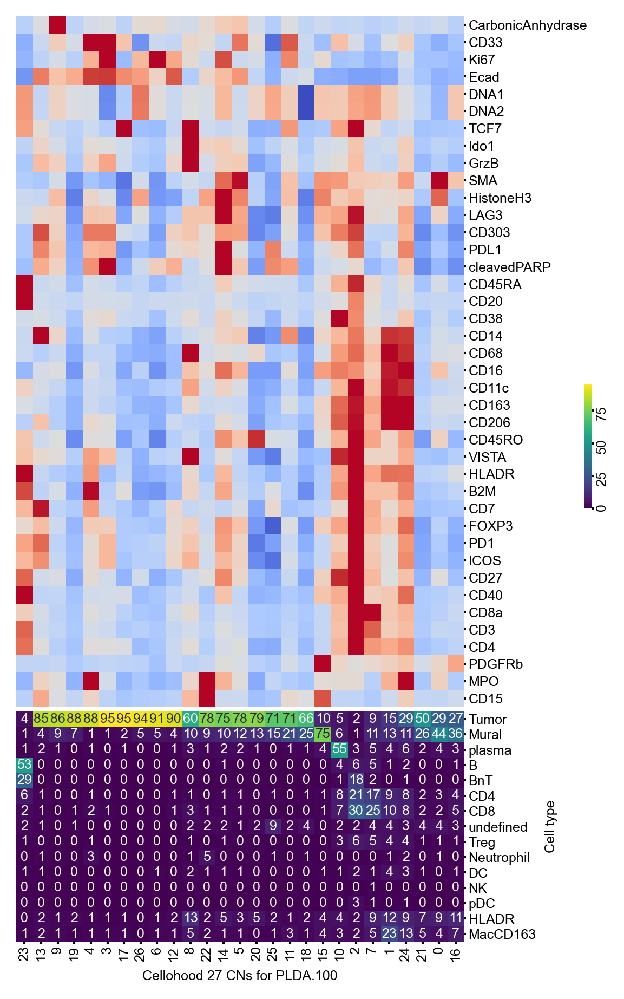

In [28]:
all_markers_distribution_colors = all_markers_map.data2d.T.applymap(marker_sm.to_rgba)


celltype_clustermap_wamc = sns.clustermap(
    celltype_percentages[celltypes].T * 100, 
    annot=True,
    fmt='.0f',
    cmap='viridis',
    xticklabels=True,
    yticklabels=True,
    col_colors=all_markers_distribution_colors,
    cbar_pos=(1.05, 0.4, 0.01, 0.1),
    annot_kws={"size": 6},
    cbar_kws={'label': ''},
    colors_ratio=0.015,
)

celltype_clustermap_wamc.ax_cbar.tick_params(labelsize=6, size=1, pad=1, rotation=90)
celltype_clustermap_wamc.ax_row_dendrogram.set_visible(False)
celltype_clustermap_wamc.ax_col_dendrogram.set_visible(False)

celltype_clustermap_wamc.ax_heatmap.set_yticklabels(celltype_clustermap_wamc.ax_heatmap.get_yticklabels(), size=6)
celltype_clustermap_wamc.ax_heatmap.xaxis.set_tick_params(size=1, left=True, pad=1)
celltype_clustermap_wamc.ax_heatmap.yaxis.set_tick_params(size=1, pad=1, rotation=0)
celltype_clustermap_wamc.ax_heatmap.set_xticklabels(celltype_clustermap_wamc.ax_heatmap.get_xticklabels(), size=6, rotation=90)
celltype_clustermap_wamc.ax_heatmap.set_xlabel(f'Cellohood {PREDICTION_NB_OF_CLUSTERS} CNs for PLDA.{int(100 * PREDICTION_VARIANCE_LEVEL)}')

celltype_clustermap_wamc.ax_col_colors.yaxis.set_tick_params(
    size=1, 
    pad=1, 
    rotation=0,
)

celltype_clustermap_wamc.ax_col_colors.set_yticklabels(
    celltype_clustermap_wamc.ax_col_colors.get_yticklabels(), 
    size=6,
)


celltype_clustermap_wamc.fig.set_dpi(PLOTTING_DPI)
celltype_clustermap_wamc.fig.set_size_inches(
    (
        0.15 * PREDICTION_NB_OF_CLUSTERS, 
        0.15 * (len(celltypes) + 0.9 * len(MARKER_COL_NAMES))))

### Cell type specific marker analysis

Now we will compute per-cell type marker expression profiles together with CN densities:

In [29]:
import numpy


marker_to_celltype_dfs = {}


for marker in MARKER_COL_NAMES:
    marker_to_celltype_dfs[marker] = pandas.pivot_table(
    cell_df, 
    values=marker, 
    index=[PREDICTION_CLUSTER_COLUMN],
    columns=[CELLTYPE_COLNAME],
    aggfunc='mean',
).fillna(0)
    


marker_ct_ipc = numpy.stack([
    marker_df.values
    for marker_df in marker_to_celltype_dfs.values()
])

celltype_to_marker_dfs = {
    ct: pandas.DataFrame(
        marker_ct_ipc[:, :, ct_ind],
        index=MARKER_COL_NAMES,
    )
    for ct_ind, ct in enumerate(celltypes)
}


celltype_to_marker_dfs_clean = {}


for celltype, cdf in celltype_to_marker_dfs.items():
    cdf_clean = cdf.copy()
    cdf_clean[MARKER_PLOT_NAME] = MARKER_COL_NAMES
    cdf_clean.set_index(MARKER_PLOT_NAME, inplace=True),
    celltype_to_marker_dfs_clean[celltype] = cdf_clean

    
celltype_to_marker_dfs_clean[ALL_PLOT_NAME] = all_markers_distribution.T
    
    
cc_densities = cell_df.groupby(
    [PREDICTION_CLUSTER_COLUMN, bag_cello_df.cellohood_neighborhood_cluster_colname]
).size().groupby(PREDICTION_CLUSTER_COLUMN).mean()

As there might be a lot of different cell type / marker combinations, below we will define a subset of these that will be analyzed. By default we gray-out the cell types with less than 0.05 percentage (5%) per cluster, but you can modify it by setting appropriate values in `celltypes_display_percentage`.

**Note:** the plot with cell type percentages and pan-celltype marker expression profiles might be handy in compilingt this list

In [30]:
celltypes_display_percentage = defaultdict(lambda: 0.05)
celltypes_display_percentage['Tumor'] = 0.15


celltypes_to_marker_to_show = {
    'B': ['CD40', 'CD20'],
    'CD4': ['LAG3'],
    'CD8': ['PD1', 'GrzB'],
    'MacCD163': ['Ido1', 'PDL1', 'CD14', 'CD68', 'CD206'],
    'Mural': ['SMA'],
    'Tumor': ['DNA1', 'Ecad', 'cleavedPARP', 'CarbonicAnhydrase',
        'CD15', 'PDL1', 'Ki67', 'B2M', 'TCF7'],
}

Now - let's visualize them:

In [31]:
all_colors_dict = {
    f'{marker}': transform_vec_to_colors( 
        vec=celltype_to_marker_dfs_clean[ALL_PLOT_NAME].loc[marker],
        colors=marker_sm,
    )
    for marker in MARKER_COL_NAMES
}

all_colors_df = pandas.DataFrame(all_colors_dict)


celltypes_cc_display = {
    ct: [
        ind_ 
        for ind_, cc_ in enumerate(celltype_percentages[ct] > celltypes_display_percentage[ct])
        if cc_
    ]
    for ct in celltypes_to_marker_to_show
}


cc_colors_dict = {}
for ct, markers in celltypes_to_marker_to_show.items():
    for marker in markers:
        cc_colors_dict[f'{ct}: {marker}'] = transform_vec_to_colors( 
                vec=celltype_to_marker_dfs_clean[ct].loc[marker],
                colors=marker_sm,
                display=celltypes_cc_display[ct] if ct in celltypes_cc_display else None,
            )


cc_marker_ct_colors = pandas.DataFrame(cc_colors_dict)

cc_marker_ct_colors[f'{ALL_PLOT_NAME}: Cell density'] = transform_vec_to_colors( 
        vec=cc_densities,
        colors=marker_sm,
)

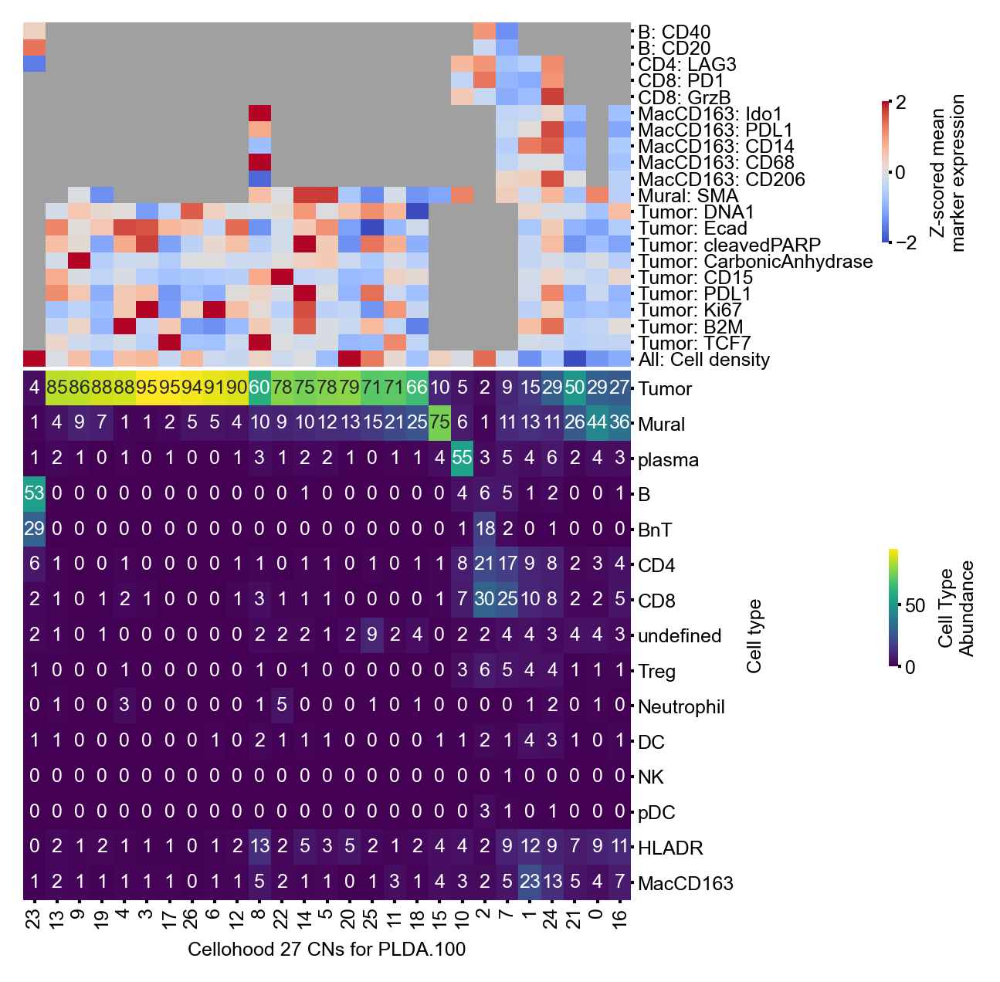

In [32]:
COLORBARS_SHIFT = 1.05


celltype_clustermap_wsm = sns.clustermap(
    (celltype_percentages[celltypes].T * 100), 
    annot=True,
    col_cluster=True,
    fmt='.0f',
    cmap='viridis',
    col_colors=cc_marker_ct_colors,
    colors_ratio=0.015,
    yticklabels=True,
    xticklabels=True,
    annot_kws={"size": 6},
    cbar_pos=[COLORBARS_SHIFT + 0.05, 0.25, 0.01, .1],
    cbar_kws={'label': 'Cell Type\nAbundance'}
)


celltype_clustermap_wsm.ax_col_dendrogram.set_visible(False)

cb_ax = celltype_clustermap_wsm.fig.add_axes([COLORBARS_SHIFT, .27, .05, .8])
cb_ax.imshow([[0, 1]])
cb_ax.set_visible(False)

cbar = celltype_clustermap_wsm.fig.colorbar(
    marker_sm, 
    drawedges=False,
    label='Z-scored mean\nmarker expression',
    ax=cb_ax,
)

cbar.outline.set_visible(False)
cbar.ax.tick_params(labelsize=6, size=1, pad=1)

celltype_clustermap_wsm.ax_cbar.tick_params(labelsize=6, size=1, pad=1)
celltype_clustermap_wsm.ax_row_dendrogram.set_visible(False)
celltype_clustermap_wsm.ax_col_dendrogram.set_visible(False)

celltype_clustermap_wsm.ax_heatmap.set_yticklabels(celltype_clustermap_wsm.ax_heatmap.get_yticklabels(), size=6)
celltype_clustermap_wsm.ax_heatmap.xaxis.set_tick_params(size=1, left=True, pad=1)
celltype_clustermap_wsm.ax_heatmap.yaxis.set_tick_params(size=1, pad=1)
celltype_clustermap_wsm.ax_heatmap.set_xticklabels(celltype_clustermap_wsm.ax_heatmap.get_xticklabels(), size=6, rotation=90)
celltype_clustermap_wsm.ax_col_colors.set_yticklabels(celltype_clustermap_wsm.ax_col_colors.get_yticklabels(), size=6)
celltype_clustermap_wsm.ax_col_colors.yaxis.set_tick_params(size=1, pad=1)
celltype_clustermap_wsm.ax_heatmap.set_xlabel(f'Cellohood {PREDICTION_NB_OF_CLUSTERS} CNs for PLDA.{int(100 * PREDICTION_VARIANCE_LEVEL)}')



celltype_clustermap_wsm.fig.set_dpi(300)
celltype_clustermap_wsm.fig.set_size_inches(
    (
        0.15 * PREDICTION_NB_OF_CLUSTERS, 
        0.15 * (len(celltypes) + 0.9 * cc_marker_ct_colors.shape[1])))

Let's combine the tables above so we can use them as color table:

In [33]:
ct_norm = matplotlib.colors.Normalize(vmin=0, vmax=celltype_percentages.values.max())
ct_cmap = plt.get_cmap('viridis')
ct_sm = matplotlib.cm.ScalarMappable(norm=ct_norm, cmap=ct_cmap)

full_cc_colors_with_ct = cc_marker_ct_colors.copy()



for celltype in celltype_clustermap.data2d.index:
    full_cc_colors_with_ct[f'{celltype}'] = [
        ct_sm.to_rgba(x ** 0.5) for x in celltype_percentages[celltype]
    ]

full_cc_colors_with_ct.index = [i for i in range(full_cc_colors_with_ct.shape[0])]

## Correlations with clinical data

Let's start with computing the counts at the image level:

In [34]:
roi_counts = pandas.pivot_table(
    cell_df, 
    values=DUMMY_COL_NAME, 
    index=['image'],
    columns=[PREDICTION_CLUSTER_COLUMN],
    aggfunc="sum",
).fillna(0)

and visualize the correlation and counts structure at the image level:

/tmp/ipykernel_648838/1769852208.py:35: UserWarning: FixedFormatter should only be used together with FixedLocator
  barplot_ax.set_xticklabels(


array([2.7, 2.7])

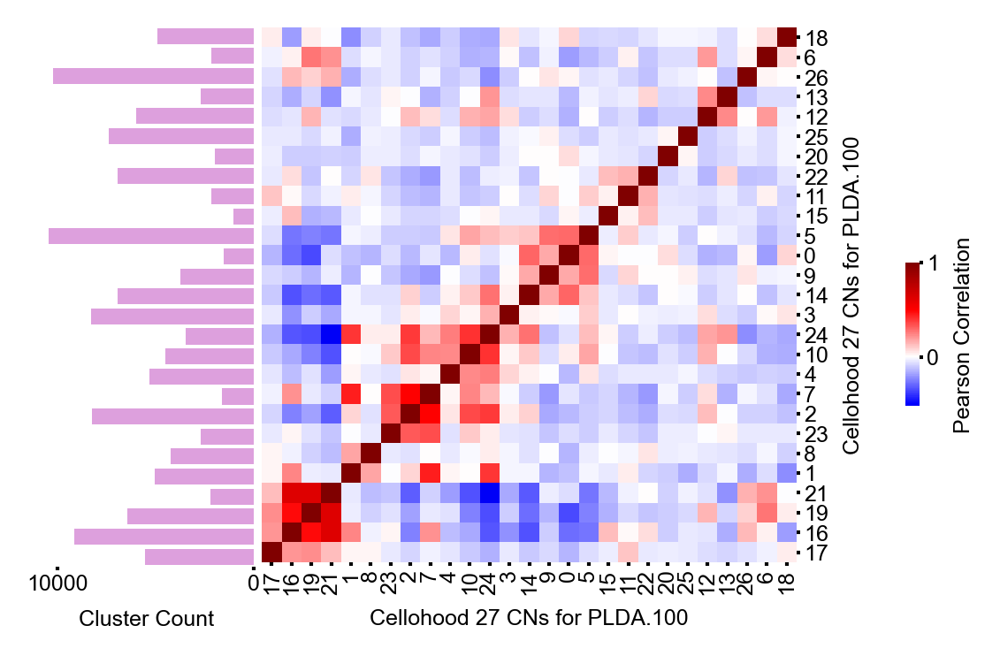

In [35]:
cluster_counts = cell_df.groupby(PREDICTION_CLUSTER_COLUMN).size()
corr_df = (roi_counts[list(range(PREDICTION_NB_OF_CLUSTERS))] ** 0.5).corr()


corr_cmap = sns.clustermap(
    corr_df,
    center=0,
    cmap='seismic',
    xticklabels=True,
    yticklabels=True,
    cbar_pos=[1.1, 0.27, 0.02, 0.2],
    cbar_kws={'label': 'Pearson Correlation'}
)

corr_cmap.ax_row_dendrogram.set_visible(False)
corr_cmap.ax_col_dendrogram.set_visible(False)

barplot_ax = corr_cmap.fig.add_axes([-.11, 0.045, .3, .755], sharey=corr_cmap.ax_heatmap)
barplot_ax.barh(
    corr_cmap.data2d.columns + 0.5,
    cluster_counts[corr_cmap.data2d.columns],
    align='center',
    height=0.8,
    color='plum',
)
barplot_ax.invert_yaxis()
barplot_ax.invert_xaxis()
barplot_ax.spines['left'].set_visible(False)
barplot_ax.spines['top'].set_visible(False)
barplot_ax.spines['right'].set_visible(False)
barplot_ax.spines['bottom'].set_visible(False)
barplot_ax.yaxis.set_visible(False)
barplot_ax.set_xlabel('Cluster Count', size=6)
barplot_ax.xaxis.set_tick_params(size=1, left=True, pad=1)
barplot_ax.set_xticklabels(
    barplot_ax.get_xticklabels(), size=6, rotation=0
)

corr_cmap.ax_cbar.tick_params(labelsize=6, size=1, pad=1)
corr_cmap.ax_row_dendrogram.set_visible(False)
corr_cmap.ax_col_dendrogram.set_visible(False)

corr_cmap.ax_heatmap.set_yticklabels(
    corr_cmap.ax_heatmap.get_yticklabels(), size=6)
corr_cmap.ax_heatmap.xaxis.set_tick_params(size=1, left=True, pad=1)
corr_cmap.ax_heatmap.yaxis.set_tick_params(size=1, pad=1, rotation=0)
corr_cmap.ax_heatmap.set_xticklabels(
    corr_cmap.ax_heatmap.get_xticklabels(), size=6, rotation=90)


corr_cmap.ax_heatmap.set_xlabel(f'Cellohood {PREDICTION_NB_OF_CLUSTERS} CNs for PLDA.{int(100 * PREDICTION_VARIANCE_LEVEL)}')
corr_cmap.ax_heatmap.set_ylabel(f'Cellohood {PREDICTION_NB_OF_CLUSTERS} CNs for PLDA.{int(100 * PREDICTION_VARIANCE_LEVEL)}')


corr_cmap.fig.set_dpi(PLOTTING_DPI)
corr_cmap.fig.set_size_inches((0.1 * PREDICTION_NB_OF_CLUSTERS, 0.1 * PREDICTION_NB_OF_CLUSTERS))
plt.gcf().get_size_inches()

and extended version of this plot with cell types and marker expressions:

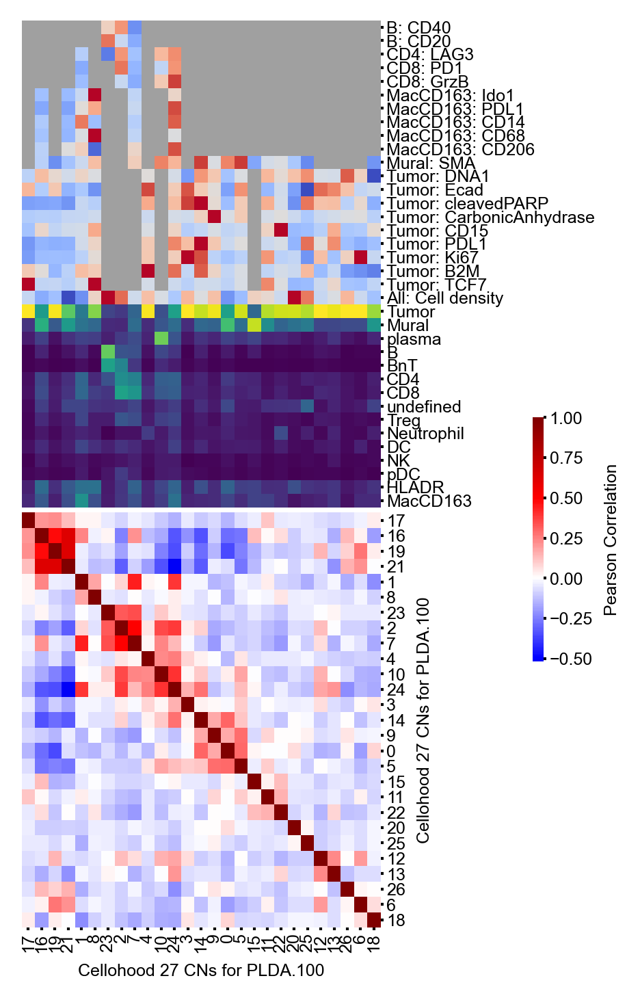

In [36]:
corr_cmap_wcn = sns.clustermap(
    corr_df,
    center=0,
    cmap='seismic',
    xticklabels=True,
    yticklabels=True,
    colors_ratio=0.012,
    col_colors=full_cc_colors_with_ct,
    cbar_pos=[1.1, 0.27, 0.02, 0.2],
    cbar_kws={'label': 'Pearson Correlation'}
)

corr_cmap_wcn.ax_row_dendrogram.set_visible(False)
corr_cmap_wcn.ax_col_dendrogram.set_visible(False)


corr_cmap_wcn.ax_cbar.tick_params(labelsize=6, size=1, pad=1)

corr_cmap_wcn.ax_heatmap.set_yticklabels(
    corr_cmap_wcn.ax_heatmap.get_yticklabels(), size=6)
corr_cmap_wcn.ax_heatmap.xaxis.set_tick_params(size=1, left=True, pad=1)
corr_cmap_wcn.ax_heatmap.yaxis.set_tick_params(size=1, pad=1, rotation=0)
corr_cmap_wcn.ax_heatmap.set_xticklabels(
    corr_cmap_wcn.ax_heatmap.get_xticklabels(), size=6, rotation=90)


corr_cmap_wcn.ax_col_colors.set_yticklabels(
    corr_cmap_wcn.ax_col_colors.get_yticklabels(), size=6)
corr_cmap_wcn.ax_col_colors.yaxis.set_tick_params(size=1, pad=1)


corr_cmap_wcn.ax_heatmap.set_xlabel(f'Cellohood {PREDICTION_NB_OF_CLUSTERS} CNs for PLDA.{int(100 * PREDICTION_VARIANCE_LEVEL)}')
corr_cmap_wcn.ax_heatmap.set_ylabel(f'Cellohood {PREDICTION_NB_OF_CLUSTERS} CNs for PLDA.{int(100 * PREDICTION_VARIANCE_LEVEL)}')


corr_cmap_wcn.fig.set_dpi(PLOTTING_DPI)
corr_cmap_wcn.fig.set_size_inches(
    (0.1 * PREDICTION_NB_OF_CLUSTERS,
     0.1 * (PREDICTION_NB_OF_CLUSTERS + 0.9 * full_cc_colors_with_ct.shape[1])))

### Image-level plots

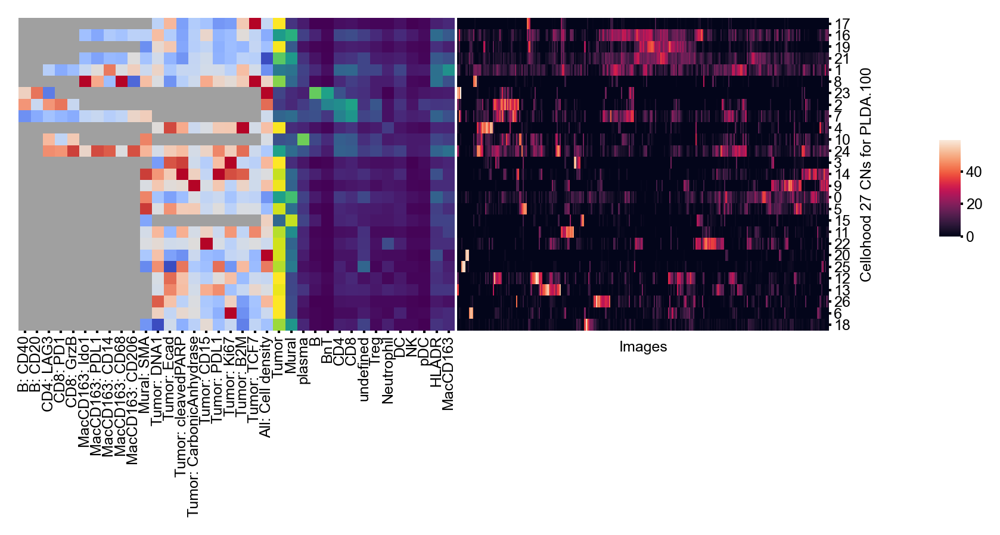

In [37]:
image_clustermap = sns.clustermap(
    (roi_counts.T ** 0.5).loc[corr_cmap_wcn.data2d.index],
    xticklabels=False,
    row_cluster=False,
    cbar_pos=[1.05, 0.37, 0.02, 0.2],
    row_colors=full_cc_colors_with_ct,
    colors_ratio=0.012,
)

image_clustermap.ax_row_dendrogram.set_visible(False)
image_clustermap.ax_col_dendrogram.set_visible(False)

image_clustermap.ax_cbar.tick_params(labelsize=6, size=1, pad=1)

image_clustermap.ax_heatmap.yaxis.set_tick_params(size=1, pad=1, rotation=0)
image_clustermap.ax_heatmap.set_yticklabels(
    image_clustermap.ax_heatmap.get_yticklabels(), size=6, rotation=0)

image_clustermap.ax_row_colors.xaxis.set_tick_params(size=1, pad=1, rotation=90)
image_clustermap.ax_row_colors.set_xticklabels(
    image_clustermap.ax_row_colors.get_xticklabels(), size=6, rotation=90)

image_clustermap.ax_heatmap.set_ylabel(
    f'Cellohood {PREDICTION_NB_OF_CLUSTERS} CNs for PLDA.{int(100 * PREDICTION_VARIANCE_LEVEL)}')

image_clustermap.ax_heatmap.set_xlabel('Images')


image_clustermap.fig.set_dpi(PLOTTING_DPI)
image_clustermap.fig.set_size_inches(
    (0.01 * roi_counts.shape[0] + 0.09 * full_cc_colors_with_ct.shape[1],
     0.1 * (PREDICTION_NB_OF_CLUSTERS)))

### Clinical data analysis

Let's start with loading a clinical data and matching the Immucan indices and EORTC indices:

In [38]:
clinical_data_df = pandas.read_excel(CLINICAL_DATA_DF)

matching_img_to_sample = data_df.groupby([IMAGE_ID_COLUMN])['sample_immu'].first()
image_to_sample = {
    image: '-'.join(sample.split('-')[:3])
    for image, sample in zip(matching_img_to_sample.index, matching_img_to_sample)
}

roi_counts_wc = roi_counts.copy()
roi_counts_wc[IMAGE_ID_COLUMN] = roi_counts_wc.index
roi_counts_wc['Eortc ID'] = roi_counts_wc['image'].apply(lambda x: image_to_sample[x])

roi_counts_wc = pandas.merge(clinical_data_df, roi_counts_wc, on='Eortc ID')
img_to_sample_immu = {}
for img, sample_immu in data_df.groupby(['image', 'sample_immu']).count().index:
    img_to_sample_immu[img] = sample_immu

sample_to_full = {
    '-'.join(key.split('-')[:3]): key
    for key in rcs.keys()
}
roi_counts_wc['Eortc ID_full'] = roi_counts_wc['image'].apply(lambda x: img_to_sample_immu[x])


roi_counts_wc['FIXT-01'] = roi_counts_wc['Eortc ID_full'].apply(lambda x: 'FIXT-01' in x)
roi_counts_wc['FIXT-02'] = roi_counts_wc['Eortc ID_full'].apply(lambda x: 'FIXT-02' in x)
roi_counts_wc['Pr.str'] = roi_counts_wc['prognosis'].apply(lambda x: 'Poor prognosis' if x == 1 else 'Good prognosis')

Now - let's prepare subsets of data:
- `roi_counts_w1_w2` - the data for which we had a pre-treatment and post-treatment data,
- `roi_counts_baseline` - only baseline patients,

In [39]:
w1_w2 = list(roi_counts_wc[roi_counts_wc['FIXT-02']]['Eortc ID'].unique())
roi_counts_w1_w2 = roi_counts_wc[roi_counts_wc['Eortc ID'].apply(lambda x: x in w1_w2)].copy()
roi_counts_w1_w2['FIXT-STR'] = roi_counts_w1_w2['FIXT-01'].apply(lambda x: 'Baseline' if x else 'Week 2')

roi_counts_w1_w2_poor = roi_counts_w1_w2[roi_counts_w1_w2['prognosis'] == 1].copy()
roi_counts_w1_w2_good = roi_counts_w1_w2[roi_counts_w1_w2['prognosis'] == 2].copy()

roi_counts_baseline = roi_counts_wc[roi_counts_wc['Eortc ID_full'].apply(lambda x: 'FIXT-01' in x)].copy()
roi_counts_baseline['Pr.str'] = roi_counts_baseline['prognosis'].apply(lambda x: 'Poor prognosis' if x == 1 else 'Good prognosis')

Now, let's prepare a code for vulcano plot generation:

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind, mannwhitneyu
import warnings
from adjustText import adjust_text
from statsmodels.stats import multitest


warnings.filterwarnings('ignore')

def create_volcano_plot(df, target_column, feature_list=None, 
                       test_type='ttest', log_transform=True,
                       fold_change_threshold=1.0, q_value_threshold=0.15,
                       figsize=(10, 8), title=None, group_0_color='blue', group_1_color='red'):
    """
    Create a volcano plot for differential analysis
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Input dataframe
    target_column : str
        Column name for grouping (should contain binary categories)
    feature_list : list, optional
        List of feature columns to analyze. If None, uses all numeric columns except target
    test_type : str, default 'ttest'
        Statistical test ('ttest' or 'mannwhitney')
    log_transform : bool, default True
        Whether to log2 transform the data before analysis
    fold_change_threshold : float, default 1.0
        Fold change threshold for significance
    q_value_threshold : float, default 0.05
        P-value threshold for significance
    figsize : tuple, default (10, 8)
        Figure size
    title : str, optional
        Plot title
    
    Returns:
    --------
    results_df : pandas.DataFrame
        DataFrame with fold changes, p-values, and significance annotations
    """
    
    # Validate input
    if target_column not in df.columns:
        raise ValueError(f"Target column '{target_column}' not found in DataFrame")
    
    # Get unique groups
    groups = df[target_column].unique()
    if len(groups) != 2:
        raise ValueError(f"Target column must have exactly 2 unique values, found {len(groups)}")
    
    print(f"Comparing groups: {groups[0]} vs {groups[1]}")
    
    # Select features
    if feature_list is None:
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        feature_list = [col for col in numeric_cols if col != target_column]
    else:
        # Validate feature list
        missing_features = [f for f in feature_list if f not in df.columns]
        if missing_features:
            raise ValueError(f"Features not found in DataFrame: {missing_features}")
    
    print(f"Analyzing {len(feature_list)} features")
    
    # Prepare results storage
    results = []
    
    # Split data into groups
    group1_data = df[df[target_column] == groups[0]]
    group2_data = df[df[target_column] == groups[1]]
    
    # Perform differential analysis for each feature
    for feature in feature_list:
        try:
            # Get feature data for both groups
            group1_values = group1_data[feature].dropna()
            group2_values = group2_data[feature].dropna()
            
            # Skip if insufficient data
            if len(group1_values) < 2 or len(group2_values) < 2:
                continue
            
            # Apply log transformation if requested
            if log_transform:
                # Add small constant to avoid log(0)
                group1_values = np.log2(group1_values + 1e-8)
                group2_values = np.log2(group2_values + 1e-8)
            
            # Calculate means
            mean1 = group1_values.mean()
            mean2 = group2_values.mean()
            
            # Calculate fold change (log2)
            fold_change = mean2 - mean1  # This is already log2 if log_transform=True
            if not log_transform:
                # Convert to log2 fold change
                if mean1 > 0:
                    fold_change = np.log2(mean2 / mean1)
                else:
                    fold_change = np.nan
            
            # Perform statistical test
            if test_type == 'ttest':
                statistic, p_value = ttest_ind(group1_values, group2_values)
            elif test_type == 'mannwhitney':
                statistic, p_value = mannwhitneyu(group1_values, group2_values, 
                                                 alternative='two-sided')
            else:
                raise ValueError("test_type must be 'ttest' or 'mannwhitney'")
            
            # Store results
            results.append({
                'feature': feature,
                'log2_fold_change': fold_change,
                'p_value': p_value,
                'neg_log10_p': -np.log10(p_value) if p_value > 0 else np.inf,
                'mean_group1': mean1,
                'mean_group2': mean2,
                'n_group1': len(group1_values),
                'n_group2': len(group2_values)
            })
            
        except Exception as e:
            print(f"Error processing feature {feature}: {str(e)}")
        
    
    # Create results DataFrame
    results_df = pd.DataFrame(results)
    results_df = results_df[~results_df['neg_log10_p'].isin([np.nan, np.inf])]

    
    _, q_vals, _, _ = multitest.multipletests(results_df['p_value'], method='fdr_bh', alpha=0.1)
    results_df['q_value'] = q_vals
    results_df['neg_log10_q'] = -np.log10(q_vals)
    
    if results_df.empty:
        raise ValueError("No valid results generated. Check your data and feature list.")
    
    # Add significance categories
    results_df['significant'] = (
        (np.abs(results_df['log2_fold_change']) >= fold_change_threshold) & 
        (results_df['q_value'] <= q_value_threshold)
    )
    
    results_df['category'] = 'Not Significant'
    results_df.loc[
        (results_df['log2_fold_change'] >= fold_change_threshold) & 
        (results_df['q_value'] <= q_value_threshold), 'category'
    ] = f'Up in {groups[1]}'
    results_df.loc[
        (results_df['log2_fold_change'] <= -fold_change_threshold) & 
        (results_df['q_value'] <= q_value_threshold), 'category'
    ] = f'Up in {groups[0]}'
    
    # Create volcano plot
    plt.figure(figsize=figsize, dpi=300)
    
    # Define colors
    colors = {
        'Not Significant': 'lightgray',
        f'Up in {groups[0]}': group_0_color,
        f'Up in {groups[1]}': group_1_color,
    }
    
    texts = []
    # Plot points
    for category in results_df['category'].unique():
        subset = results_df[results_df['category'] == category]
        plt.scatter(subset['log2_fold_change'], subset['neg_log10_q'], 
                   c=colors[category], label=category, alpha=0.7, s=10)
        for _, row in subset.iterrows():
            if not row['significant']:
                continue
            texts.append(plt.text(
                row['log2_fold_change'] - 0.6, 
                row['neg_log10_q'] + 0.1, 
                row['feature'],
                ha='center',
                size=6,
            ))
    ax = plt.gca()
    
    adjust_text(texts, only_move={'points':'y', 'texts':'y'}, arrowprops=dict(arrowstyle="->", color='k', lw=0.0))

    plt.axhline(y=-np.log10(q_value_threshold), color='black', linestyle='--', alpha=0.5)
    
    # Customize plot
    plt.xlabel('Log2 Fold Change', fontsize=6)
    plt.ylabel('-Log10 Q-value', fontsize=6)
    if title is None:
        title = f'Volcano Plot: {groups[1]} vs {groups[0]}'
    plt.title(title, fontsize=6, fontweight='bold')
    plt.grid(True, alpha=0.3)

    plt.text(plt.xlim()[1] * 1.15, -np.log10(q_value_threshold) + 0.1, 
             f'q ≤ {q_value_threshold}', ha='right', fontsize=6)
    
    ax = plt.gca()
    ax.spines[['top', 'right']].set_visible(False)
    
    plt.tight_layout()
    ax.xaxis.set_tick_params(size=2)
    ax.yaxis.set_tick_params(size=2)
    ax.set_xticklabels(ax.get_xticklabels(), size=6)
    ax.set_yticklabels(ax.get_yticklabels(), size=6)
    plt.show()
    
    # Print summary
    print(f"\nSummary:")
    print(f"Total features analyzed: {len(results_df)}")
    print(f"Significant features: {results_df['significant'].sum()}")
    print(f"Up in {groups[0]}: {sum(results_df['category'] == f'Up in {groups[0]}')}")
    print(f"{list(results_df[results_df['category'] == f'Up in {groups[0]}'].index)}")
    print(f"Up in {groups[1]}: {sum(results_df['category'] == f'Up in {groups[1]}')}")
    print(f"{list(results_df[results_df['category'] == f'Up in {groups[1]}'].index)}")

    
    return results_df

Now, let's generate a plot for general differences in CN abundances between W1 and W2:

Comparing groups: Baseline vs Week 2
Analyzing 27 features


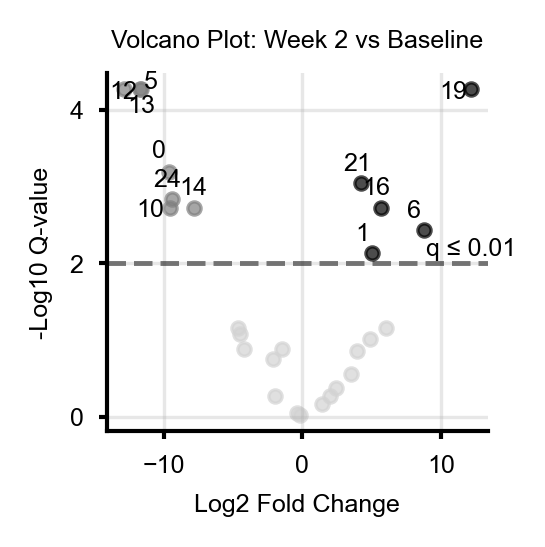


Summary:
Total features analyzed: 27
Significant features: 12
Up in Baseline: 7
[0, 5, 10, 12, 13, 14, 24]
Up in Week 2: 5
[1, 6, 16, 19, 21]


In [41]:
w1_w2_results = create_volcano_plot(
    df=roi_counts_w1_w2,
    figsize=(2, 2),
    target_column='FIXT-STR',  # Replace with your target column
    feature_list=list(range(PREDICTION_NB_OF_CLUSTERS)),  # Or provide specific feature list
    test_type='ttest',
    fold_change_threshold=1.0,
    q_value_threshold=0.01,
    log_transform=True,
    group_0_color='grey',
    group_1_color='k',
)

Now, let's generate a plot for general differences in CN abundances between good prognosis and bad prognosis:

Comparing groups: Poor prognosis vs Good prognosis
Analyzing 27 features


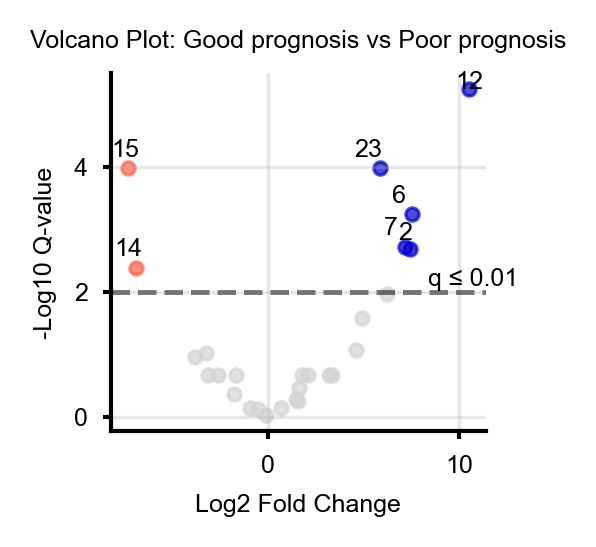


Summary:
Total features analyzed: 27
Significant features: 7
Up in Poor prognosis: 2
[14, 15]
Up in Good prognosis: 5
[2, 6, 7, 12, 23]


In [42]:
baseline_results = create_volcano_plot(
    df=roi_counts_baseline,
    target_column='Pr.str',  # Replace with your target column
    feature_list=list(range(PREDICTION_NB_OF_CLUSTERS)),  # Or provide specific feature list
    test_type='ttest',
    fold_change_threshold=1.0,
    q_value_threshold=0.01,
    figsize=(2, 2),
    log_transform=True,
    group_1_color='#0000CD',
    group_0_color='#FF6347',
)

Now, let's generate a plot for general differences in CN abundances between W1 and W2 for poor prognosis patients:

Comparing groups: Baseline vs Week 2
Analyzing 27 features


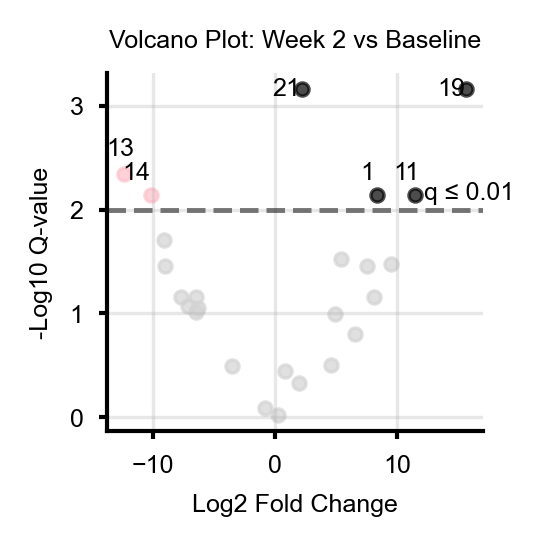


Summary:
Total features analyzed: 25
Significant features: 6
Up in Baseline: 2
[13, 14]
Up in Week 2: 4
[1, 11, 19, 21]


In [43]:
baseline_results = create_volcano_plot(
    df=roi_counts_w1_w2_poor,
    target_column='FIXT-STR',  # Replace with your target column
    feature_list=list(range(PREDICTION_NB_OF_CLUSTERS)),  # Or provide specific feature list
    test_type='ttest',
    fold_change_threshold=1.0,
    q_value_threshold=0.01,
    log_transform=True,
    figsize=(2, 2),
    group_0_color='pink',
    group_1_color='k',
)

and finally, let's generate a plot for general differences in CN abundances between W1 and W2 for poor prognosis patients:

Comparing groups: Baseline vs Week 2
Analyzing 27 features


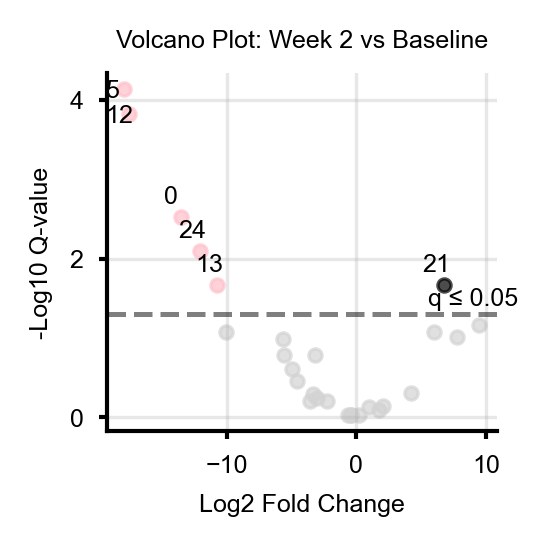


Summary:
Total features analyzed: 27
Significant features: 6
Up in Baseline: 5
[0, 5, 12, 13, 24]
Up in Week 2: 1
[21]


In [44]:
baseline_results = create_volcano_plot(
    df=roi_counts_w1_w2_good,
    target_column='FIXT-STR',  # Replace with your target column
    feature_list=list(range(PREDICTION_NB_OF_CLUSTERS)),  # Or provide specific feature list
    test_type='ttest',
    fold_change_threshold=1.0,
    q_value_threshold=0.05,
    log_transform=True,
    figsize=(2, 2),
    group_0_color='pink',
    group_1_color='k',
)

### Example image generation:

#### For CN14:

In [45]:
CLUSTER_TO_VISUALIZE = 14

TOP_IMAGES_14 = [
    'IMMUcan_Batch20230524_SYN_S-230327-00020_004.tiff',
    'IMMUcan_Batch20230524_SYN_S-230329-00008_003.tiff',
    'IMMUcan_Batch20230524_SYN_S-230323-00014_001.tiff',
    'IMMUcan_Batch20230524_SYN_S-230323-00014_003.tiff',
] # SUBSET FOR CLARITY

IMMUcan_Batch20230524_SYN_S-230327-00020_004.tiff


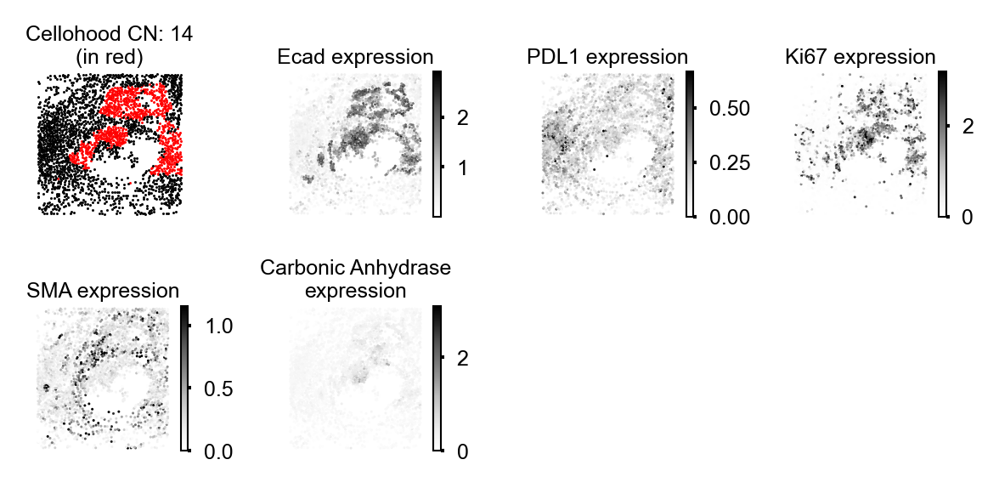

IMMUcan_Batch20230524_SYN_S-230329-00008_003.tiff


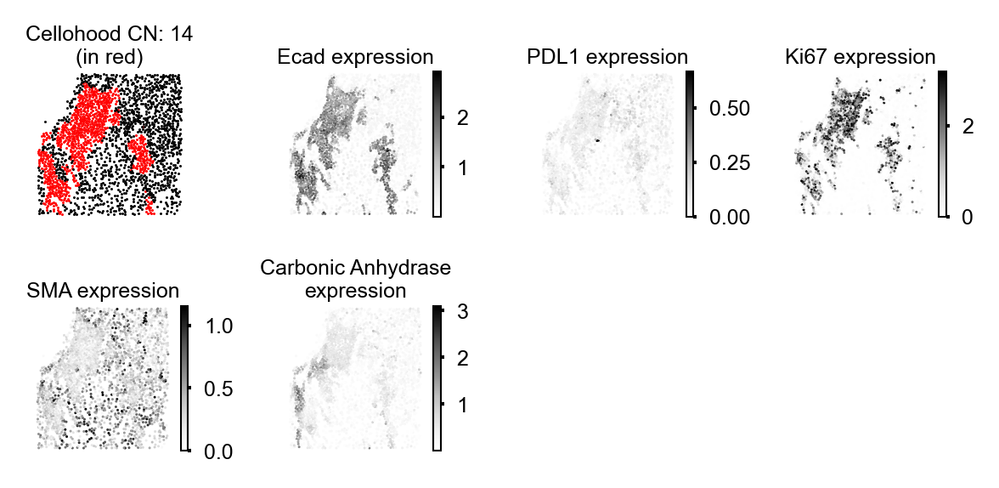

IMMUcan_Batch20230524_SYN_S-230323-00014_001.tiff


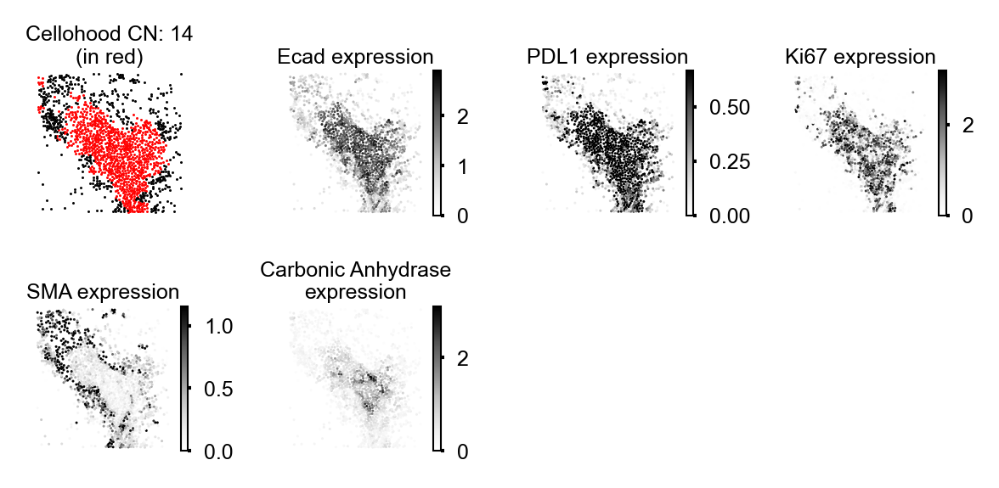

IMMUcan_Batch20230524_SYN_S-230323-00014_003.tiff


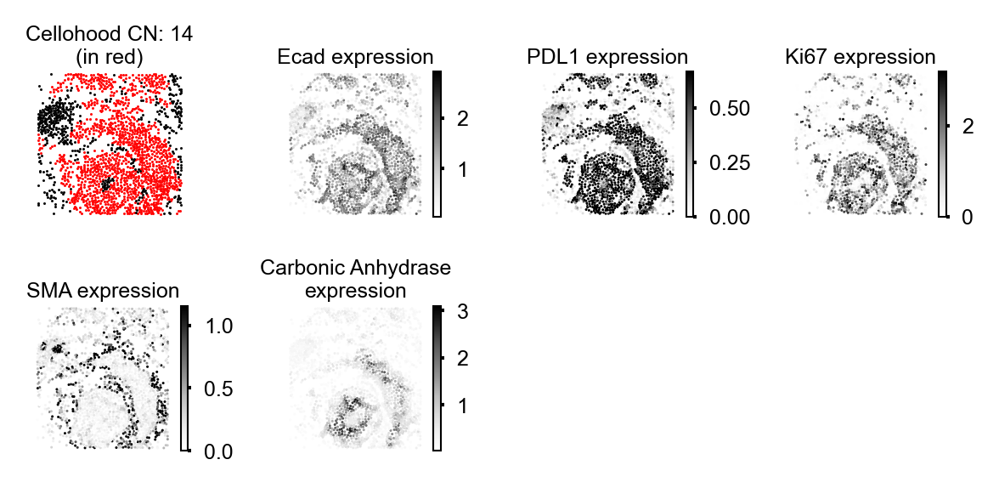

In [46]:
for image in TOP_IMAGES_14:
    print(image)
    image_df = cell_df[cell_df['image'] == image]
    plt.figure(figsize=(4, 2), dpi=300)
    plt.subplot(2, 4, 1)
    plt.scatter(
        image_df['Pos_X'][image_df['1.0:27'] == CLUSTER_TO_VISUALIZE],
        image_df['Pos_Y'][image_df['1.0:27'] == CLUSTER_TO_VISUALIZE],
        c='r',
        s=0.5,
        label=f'{CLUSTER_TO_VISUALIZE}',
        linewidth=0.01,
    )
    plt.scatter(
        image_df['Pos_X'][image_df['1.0:27'] != CLUSTER_TO_VISUALIZE],
        image_df['Pos_Y'][image_df['1.0:27'] != CLUSTER_TO_VISUALIZE],
        c='k',
        s=0.5,
        label=f'Rest',
        linewidth=0.01,
    )
    plt.axis('off')
    
    plt.title(f'Cellohood CN: {CLUSTER_TO_VISUALIZE}\n(in red)', size=6, pad=1)
    plt.subplot(2, 4, 2)
    plt.scatter(
        image_df['Pos_X'],
        image_df['Pos_Y'],
        c=image_df['Ecad'],
        vmax=numpy.quantile(cell_df['Ecad'], 0.99),
        s=0.5,
        cmap='Greys',
        linewidth=0.01,
    )
    plt.title('Ecad expression', size=6, pad=1)
    cb = plt.colorbar(fraction=0.046, pad=0.04, drawedges=False)
    cb.ax.tick_params(labelsize=6, size=1)
    cb.outline.set_linewidth(0.5)
    plt.axis('off')
    plt.subplot(2, 4, 3)
    plt.scatter(
        image_df['Pos_X'],
        image_df['Pos_Y'],
        c=image_df['PDL1'],
        vmax=numpy.quantile(cell_df['PDL1'], 0.99),
        s=0.5,
        cmap='Greys',
        linewidth=0.01,
    )
    plt.axis('off')
    plt.title('PDL1 expression', size=6, pad=1)
    cb = plt.colorbar(fraction=0.046, pad=0.04, drawedges=False)
    cb.ax.tick_params(labelsize=6, size=1)
    cb.outline.set_linewidth(0.5)
    plt.subplot(2, 4, 4)
    plt.scatter(
        image_df['Pos_X'],
        image_df['Pos_Y'],
        c=image_df['Ki67'],
        vmax=numpy.quantile(cell_df['Ki67'], 0.99),
        s=0.5,
        cmap='Greys',
        linewidth=0.01,
    )
    plt.axis('off')
    plt.title('Ki67 expression', size=6, pad=1)
    cb = plt.colorbar(fraction=0.046, pad=0.04, drawedges=False)
    cb.ax.tick_params(labelsize=6, size=1)
    cb.outline.set_linewidth(0.5)
    plt.subplot(2, 4, 5)
    plt.scatter(
        image_df['Pos_X'],
        image_df['Pos_Y'],
        c=image_df['SMA'],
        vmax=numpy.quantile(cell_df['SMA'], 0.99),
        s=0.5,
        cmap='Greys',
        linewidth=0.01,
    )
    plt.axis('off')
    plt.title('SMA expression', size=6, pad=1)
    cb = plt.colorbar(fraction=0.046, pad=0.04, drawedges=False)
    cb.ax.tick_params(labelsize=6, size=1)
    cb.outline.set_linewidth(0.5)
    plt.subplot(2, 4, 6)
    plt.scatter(
        image_df['Pos_X'],
        image_df['Pos_Y'],
        c=image_df['CarbonicAnhydrase'],
        vmax=numpy.quantile(cell_df['CarbonicAnhydrase'], 0.99),
        s=0.5,
        cmap='Greys',
        linewidth=0.01,
    )
    plt.axis('off')
    plt.title('Carbonic Anhydrase\nexpression', size=6, pad=1)
    cb = plt.colorbar(fraction=0.046, pad=0.04, drawedges=False)
    cb.ax.tick_params(labelsize=6, size=1)
    cb.outline.set_linewidth(0.5)

    plt.tight_layout()
    plt.show()

In [47]:
CLUSTER_TO_VISUALIZE = 23

TOP_IMAGES = roi_counts_wc.iloc[roi_counts_wc[CLUSTER_TO_VISUALIZE].argsort()[-20:]]['image']

235    2
Name: prognosis, dtype: int64


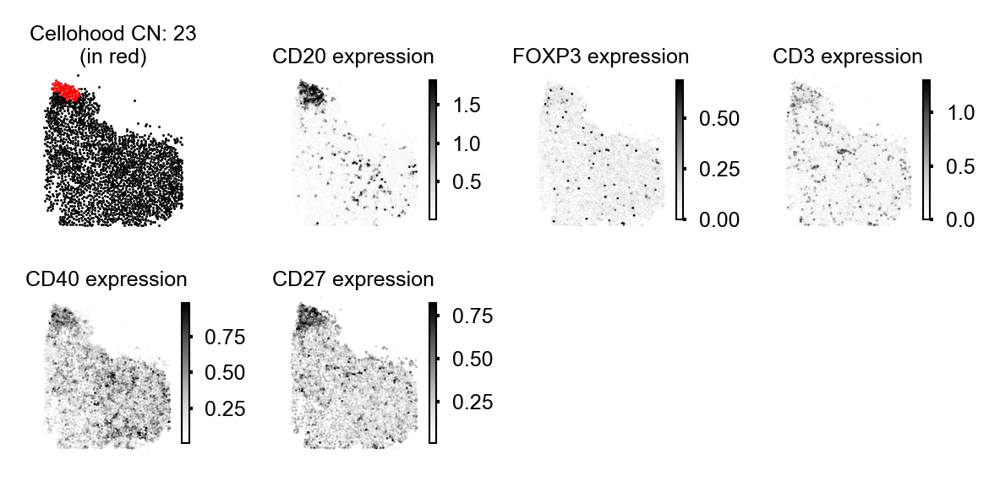

186    2
Name: prognosis, dtype: int64


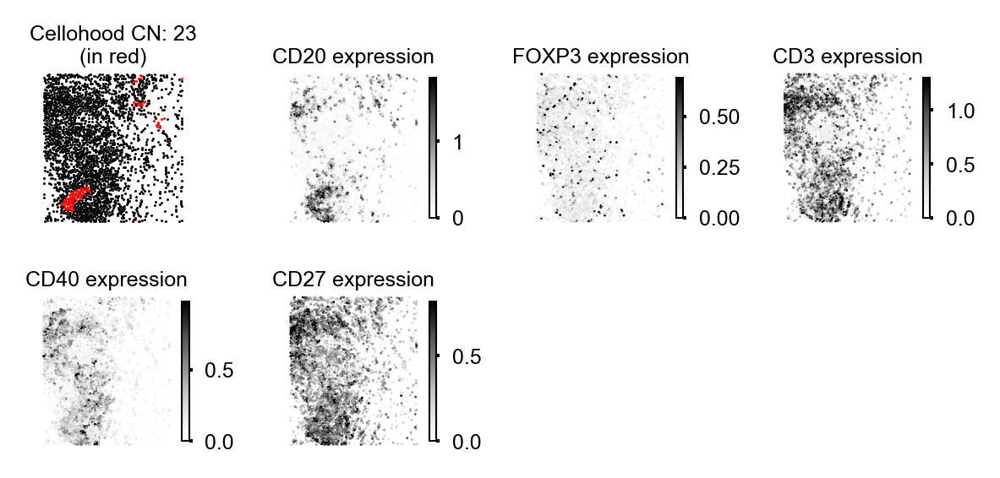

30    2
Name: prognosis, dtype: int64


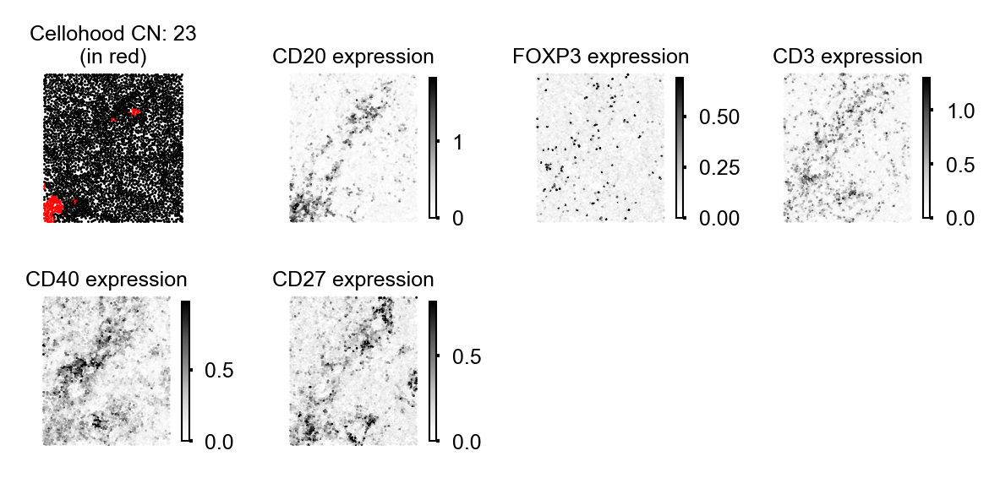

97    2
Name: prognosis, dtype: int64


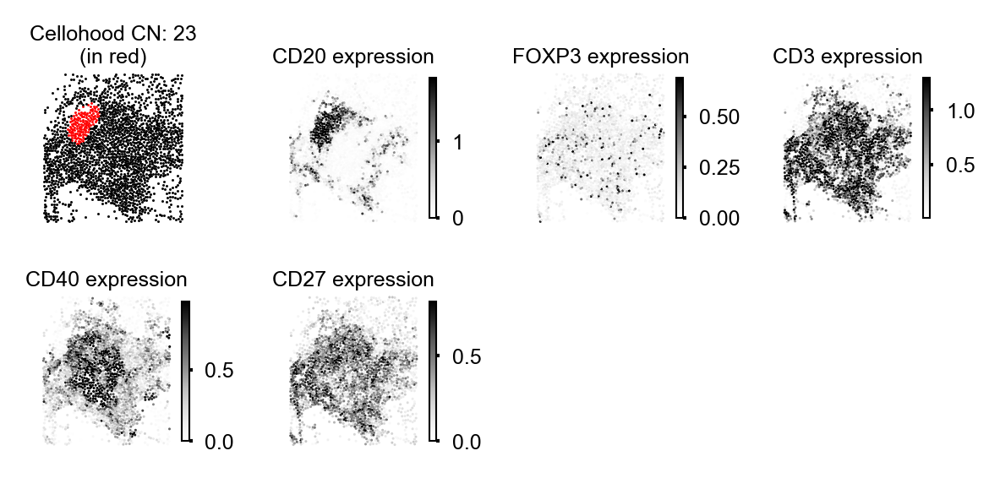

144    2
Name: prognosis, dtype: int64


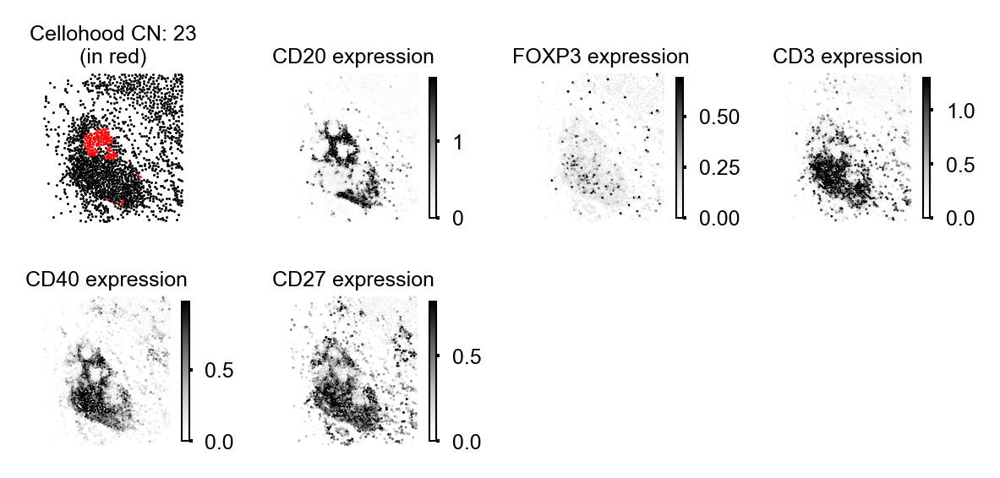

234    2
Name: prognosis, dtype: int64


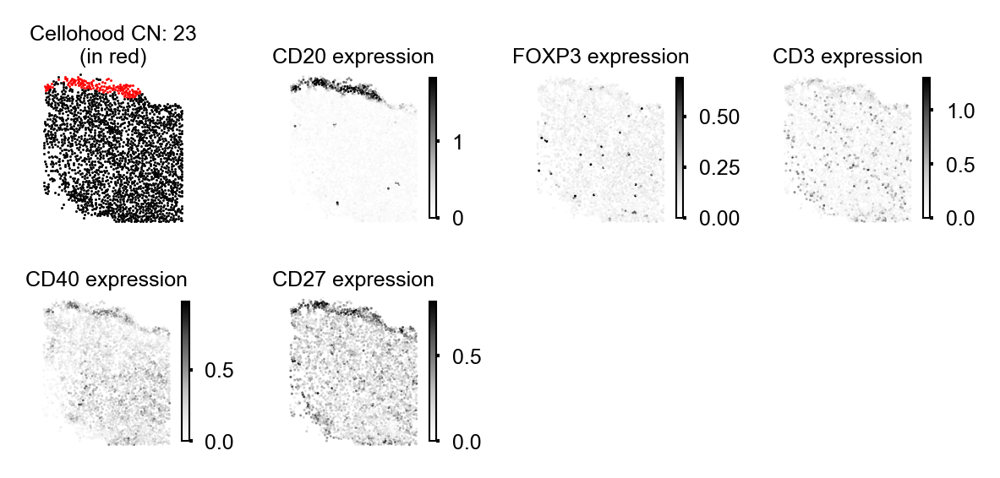

170    2
Name: prognosis, dtype: int64


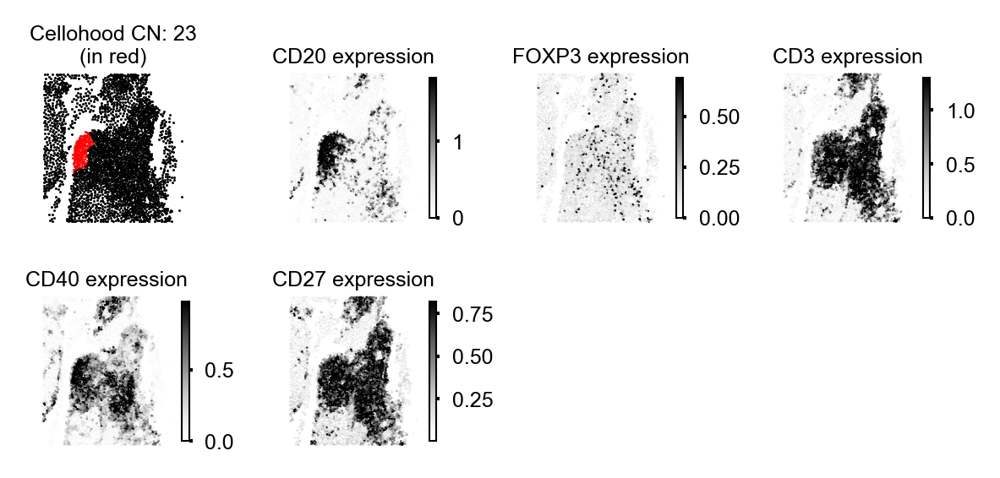

206    2
Name: prognosis, dtype: int64


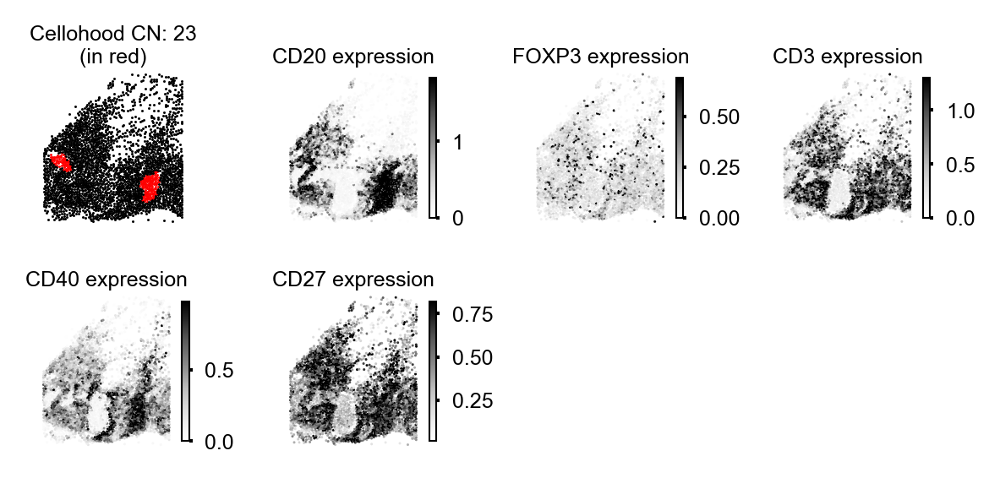

156    2
Name: prognosis, dtype: int64


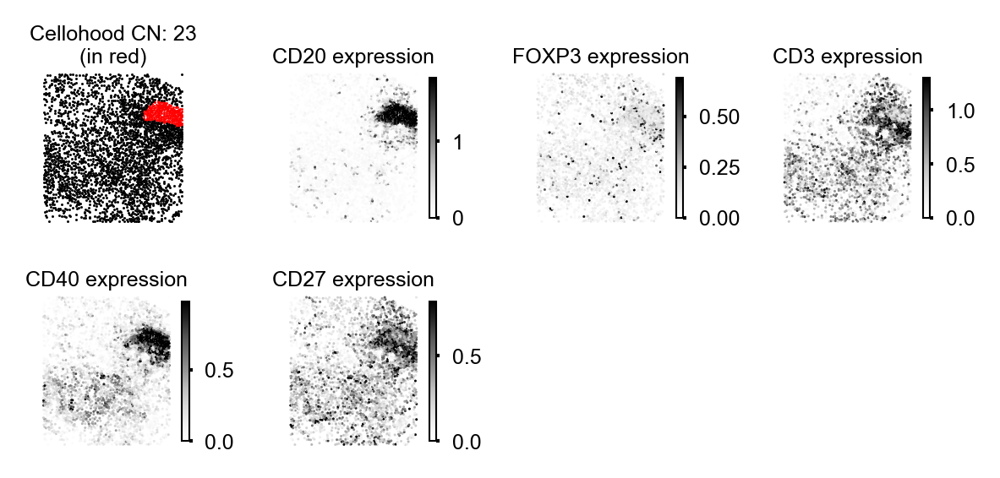

169    2
Name: prognosis, dtype: int64


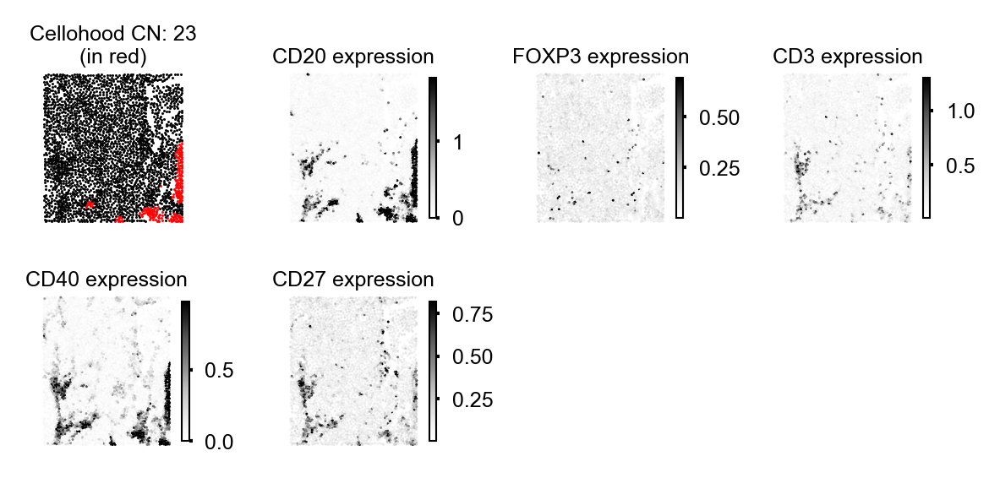

165    2
Name: prognosis, dtype: int64


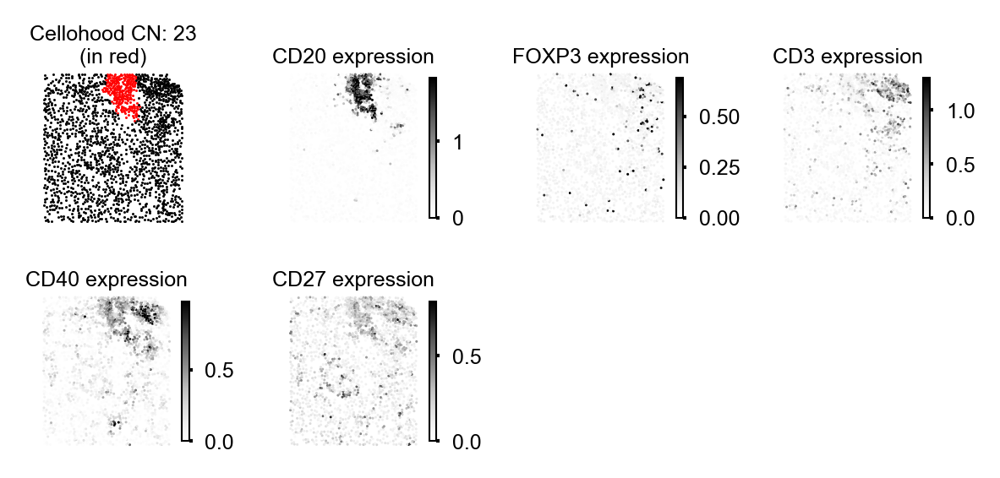

189    2
Name: prognosis, dtype: int64


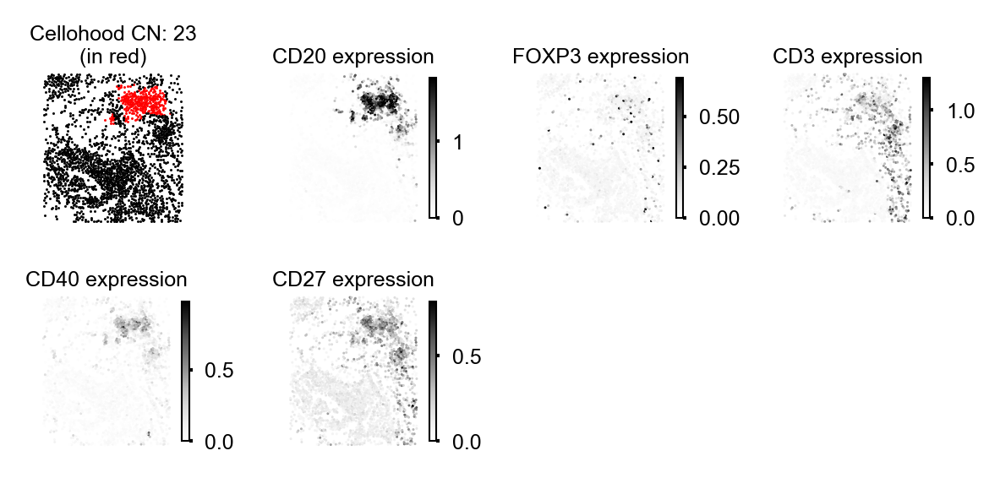

270    1
Name: prognosis, dtype: int64


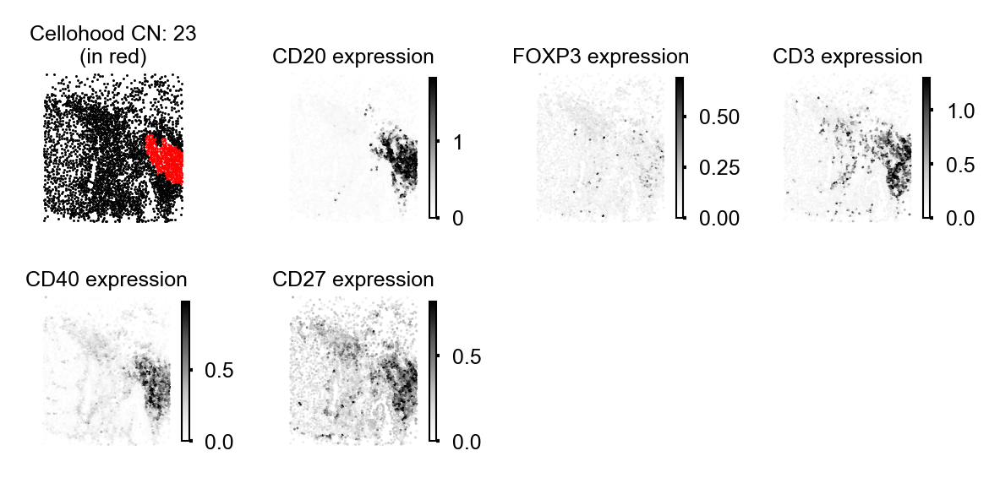

72    2
Name: prognosis, dtype: int64


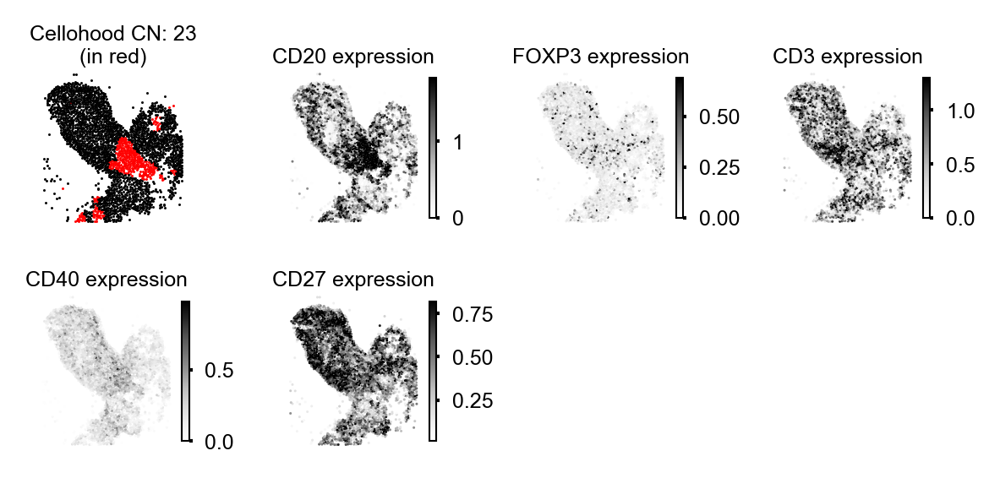

158    2
Name: prognosis, dtype: int64


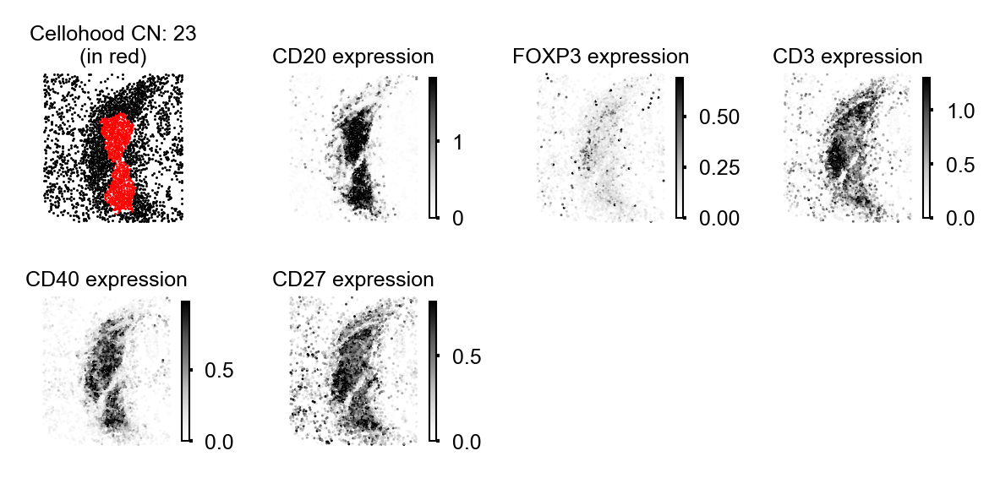

124    2
Name: prognosis, dtype: int64


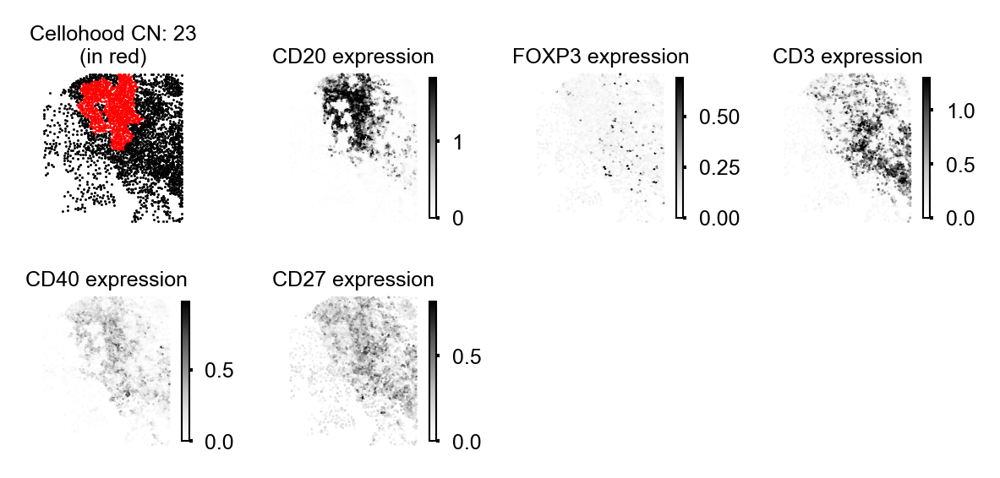

162    2
Name: prognosis, dtype: int64


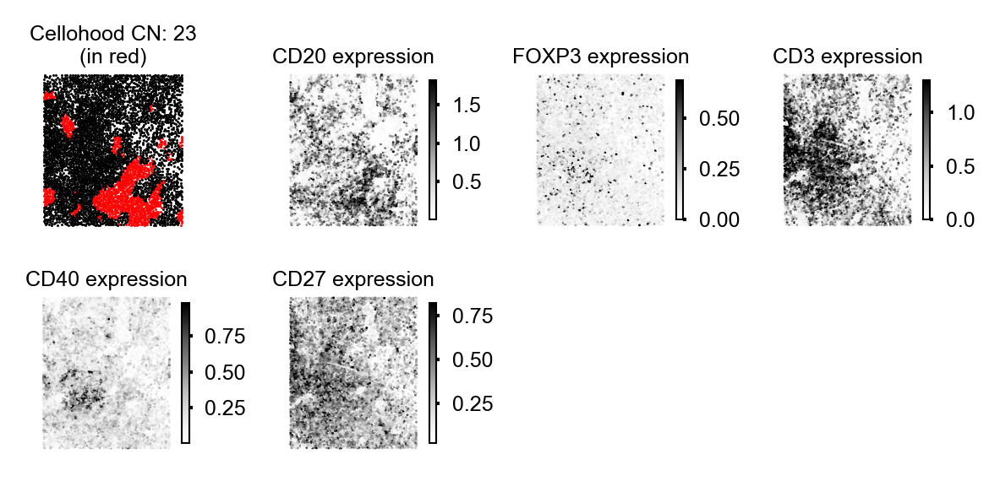

33    2
Name: prognosis, dtype: int64


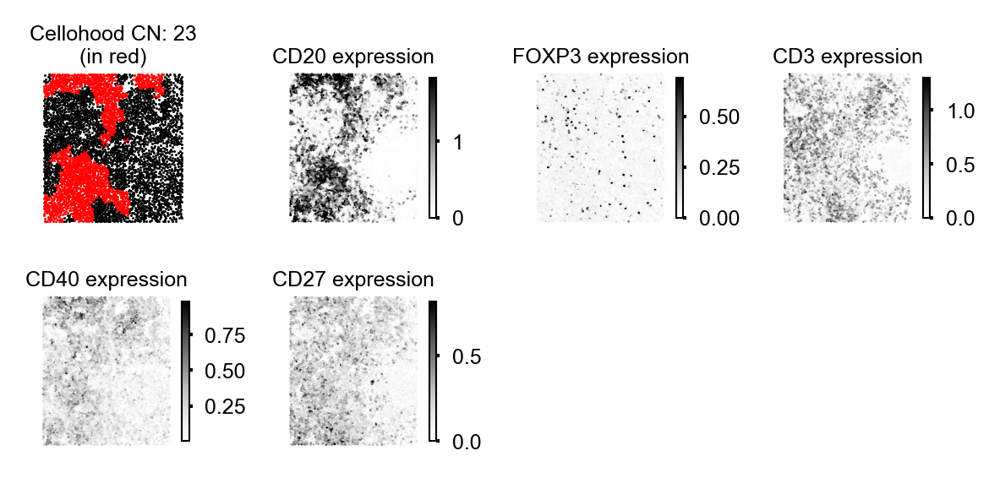

28    2
Name: prognosis, dtype: int64


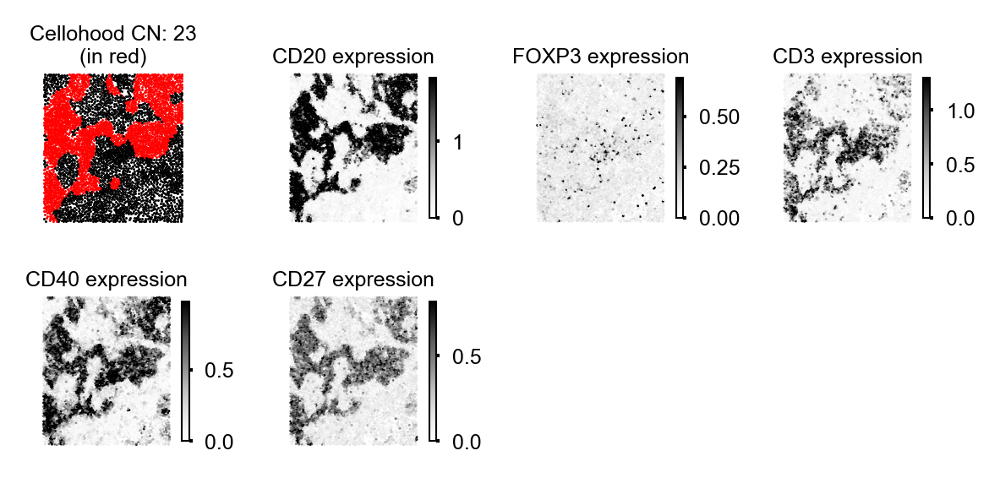

166    2
Name: prognosis, dtype: int64


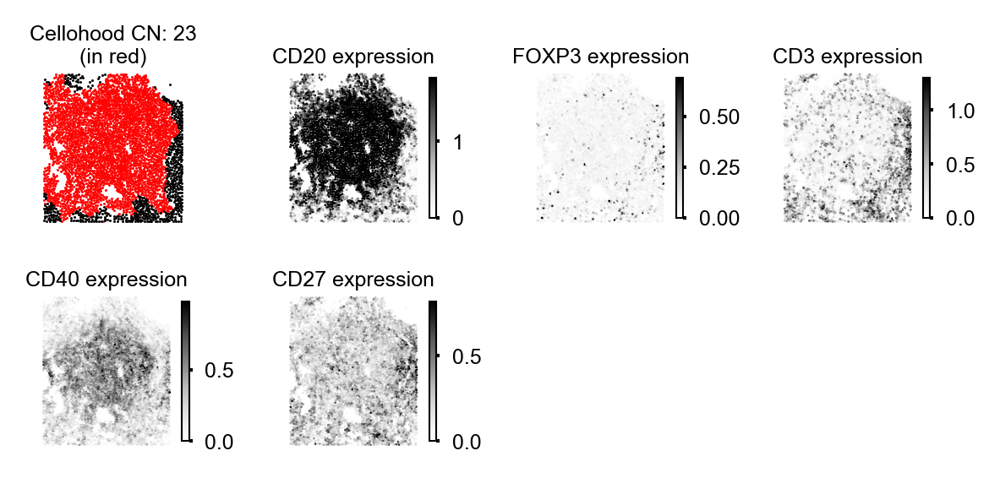

In [48]:
for image in TOP_IMAGES:
    print(roi_counts_wc[roi_counts_wc['image'] == image]['prognosis'])
    image_df = cell_df[cell_df['image'] == image]
    plt.figure(figsize=(4, 2), dpi=300)
    plt.subplot(2, 4, 1)
    plt.scatter(
        image_df['Pos_X'][image_df['1.0:27'] == CLUSTER_TO_VISUALIZE],
        image_df['Pos_Y'][image_df['1.0:27'] == CLUSTER_TO_VISUALIZE],
        c='r',
        s=0.5,
        label=f'{CLUSTER_TO_VISUALIZE}',
        linewidth=0.01,
    )
    plt.scatter(
        image_df['Pos_X'][image_df['1.0:27'] != CLUSTER_TO_VISUALIZE],
        image_df['Pos_Y'][image_df['1.0:27'] != CLUSTER_TO_VISUALIZE],
        c='k',
        s=0.5,
        label=f'Rest',
        linewidth=0.01,
    )
    plt.axis('off')
    
    plt.title(f'Cellohood CN: {CLUSTER_TO_VISUALIZE}\n(in red)', size=6, pad=1)
    plt.subplot(2, 4, 2)
    plt.scatter(
        image_df['Pos_X'],
        image_df['Pos_Y'],
        c=image_df['CD20'],
        vmax=numpy.quantile(cell_df['CD20'], 0.99),
        s=0.5,
        cmap='Greys',
        linewidth=0.01,
    )
    plt.title('CD20 expression', size=6, pad=1)
    cb = plt.colorbar(fraction=0.046, pad=0.04, drawedges=False)
    cb.ax.tick_params(labelsize=6, size=1)
    cb.outline.set_linewidth(0.5)
    plt.axis('off')
    plt.subplot(2, 4, 3)
    plt.scatter(
        image_df['Pos_X'],
        image_df['Pos_Y'],
        c=image_df['FOXP3'],
        vmax=numpy.quantile(cell_df['FOXP3'], 0.99),
        s=0.5,
        cmap='Greys',
        linewidth=0.01,
    )
    plt.axis('off')
    plt.title('FOXP3 expression', size=6, pad=1)
    cb = plt.colorbar(fraction=0.046, pad=0.04, drawedges=False)
    cb.ax.tick_params(labelsize=6, size=1)
    cb.outline.set_linewidth(0.5)
    plt.subplot(2, 4, 4)
    plt.scatter(
        image_df['Pos_X'],
        image_df['Pos_Y'],
        c=image_df['CD3'],
        vmax=numpy.quantile(cell_df['CD3'], 0.99),
        s=0.5,
        cmap='Greys',
        linewidth=0.01,
    )
    plt.axis('off')
    plt.title('CD3 expression', size=6, pad=1)
    cb = plt.colorbar(fraction=0.046, pad=0.04, drawedges=False)
    cb.ax.tick_params(labelsize=6, size=1)
    cb.outline.set_linewidth(0.5)
    plt.subplot(2, 4, 5)
    plt.scatter(
        image_df['Pos_X'],
        image_df['Pos_Y'],
        c=image_df['CD40'],
        vmax=numpy.quantile(cell_df['CD40'], 0.99),
        s=0.5,
        cmap='Greys',
        linewidth=0.01,
    )
    plt.axis('off')
    plt.title('CD40 expression', size=6, pad=1)
    cb = plt.colorbar(fraction=0.046, pad=0.04, drawedges=False)
    cb.ax.tick_params(labelsize=6, size=1)
    cb.outline.set_linewidth(0.5)
    plt.subplot(2, 4, 6)
    plt.scatter(
        image_df['Pos_X'],
        image_df['Pos_Y'],
        c=image_df['CD27'],
        vmax=numpy.quantile(cell_df['CD27'], 0.99),
        s=0.5,
        cmap='Greys',
        linewidth=0.01,
    )
    plt.axis('off')
    plt.title('CD27 expression', size=6, pad=1)
    cb = plt.colorbar(fraction=0.046, pad=0.04, drawedges=False)
    cb.ax.tick_params(labelsize=6, size=1)
    cb.outline.set_linewidth(0.5)

    plt.tight_layout()
    plt.show()